# AC magnetometry with an NV center

<span style="font-variant: small-caps;">Simphony</span> is a Python package designed for **simulating the spin dynamics** of point
defects, in particular the nitrogen-vacancy (NV) center, which is surrounded by nuclear spins and
serves as a **central-spin quantum register**.

NV centers are widely used to detect **oscillating magnetic fields**, since they combine
atomic-scale spatial resolution with high sensitivity. In this example notebook we simulate such a
measurement from end to end: the electron spin is driven by **dynamical decoupling sequences**, it
accumulates phase from an external AC field during the free-evolution intervals, and the resulting
population difference is read out.

We will:
- derive the **phase accumulated** by the electron spin during a pulse sequence
- implement a **Hahn echo** and locate the AC resonance by scanning the free-evolution time
- extend the measurement to **CPMG** sequences with $n = 2, 3, 6, 10$ $\pi$-pulses
- measure the **spectral resolution** and confirm that it improves as $1/n$

## Phase accumulation during a pulse sequence

In the absence of the AC field, the NV electron spin Hamiltonian (zero-field splitting plus static
Zeeman term) is **diagonal in the $S_z$ basis**, with eigenstates $|m_s\rangle$
($m_s = 0, \pm 1$). An oscillating field $B(t)$ applied along the NV axis adds the perturbation

$$
H_{\text{AC}}(t) = \gamma_e\, B(t)\, S_z ,
$$

which is diagonal in the same basis and therefore **commutes with the unperturbed Hamiltonian** at
every instant.

Because $H_{\text{AC}}(t)$ commutes with $H_0$, it cannot drive transitions between the $m_s$
levels. Provided it also varies slowly compared with the other NV transition frequencies, the
adiabatic theorem guarantees that the spin remains in whichever instantaneous eigenstate it started
in, picking up an extra **dynamical phase**

$$
\phi_{m_s}(t) = -2 \pi\,m_s\, \gamma_e \int_0^t B(t')\, dt' .
$$

The factor of $2\pi$ appears because <span style="font-variant: small-caps;">Simphony</span> works in $\hbar = 1/2\pi$ units. For a
superposition of the two qubit sublevels ($m_s = 0$ and $m_s = -1$ in the default
<span style="font-variant: small-caps;">Simphony</span> NV model), the **relative phase** between the two branches accumulates as

$$
\Delta\Phi(t) = \phi_{-1}(t) - \phi_0(t) = 2 \pi \gamma_e \int_0^t B(t')\, dt' .
$$

A resonant $\pi$-pulse **swaps the populations and coherences** of the two qubit levels, which is
equivalent to reversing the sign of $m_s$ for the remainder of the sequence. The phase accumulated
during each subsequent free-evolution interval therefore enters with the **opposite sign**. Summing
over all intervals between $m$ pulses applied at times $t_1 < t_2 < \cdots < t_m$ gives the
alternating-sign structure

$$
\Delta \Phi = 2 \pi\, \gamma_e \left( \int_0^{t_1} - \int_{t_1}^{t_2} + \cdots + (-1)^m \int_{t_m}^{t} \right) B(t') \, dt' ,
$$

which is the formula used throughout this notebook.

The derivation assumes the AC field varies slowly compared with the gaps to states **outside** the
qubit subspace, i.e. $f_{\text{AC}} \ll D,\, \gamma_e B_0$. This is comfortably satisfied for the
kHz–MHz signals that AC magnetometry targets.

**Reference.** B. Naydenov, F. Dolde, L. T. Hall, C. Shin, H. Fedder, L. C. L. Hollenberg,
F. Jelezko, and J. Wrachtrup, *Dynamical decoupling of a single-electron spin at room temperature*,
[Phys. Rev. B **83**, 081201(R) (2011)](https://doi.org/10.1103/PhysRevB.83.081201).

## Dynamical decoupling sequences

For an oscillating field $B(t) = B_{\text{AC}} \cos(2\pi f_{\text{AC}} t + \varphi)$, the phase
accumulated by the spin depends on **how the $\pi$-pulses are placed** relative to the field
oscillation. The two most common sequences are:

- **Hahn echo**: $\frac{\pi}{2}_x - \tau - \pi_x - \tau - \frac{\pi}{2}_x$
- **Carr–Purcell–Meiboom–Gill (CPMG)**: $\frac{\pi}{2}_x - (\tau - \pi_y - \tau)^n - \frac{\pi}{2}_x$

where the subscripts denote the rotation axes. The accumulated phase $\Delta \Phi$ is **maximal when
the pulse spacing is resonant** with the AC period: $f_{\text{AC}} = 1/(2\tau)$ for the Hahn echo and
$f_{\text{AC}} = 1/(4\tau)$ for CPMG, since there the pulse spacing is $2\tau$. On resonance the AC
field contributes constructively during every free-evolution interval, while **static noise is
refocused** by the $\pi$-pulses.

## Optical readout

The accumulated phase is not observed directly; it is converted into a **population difference**.
The $m_s = 0$ sublevel decays back to the orbital ground state largely through spin-conserving
fluorescence, whereas the $m_s = \pm 1$ sublevels have a significant branching ratio into a
metastable singlet via a **spin-selective intersystem crossing**. That path is dark, so population
in $m_s = \pm 1$ appears as *reduced* photoluminescence.

After the final $\pi/2$-pulse the population difference between the two qubit levels is mapped onto
the accumulated phase as

$$
\langle Z \rangle \propto \cos(\Delta\Phi),
$$

a Ramsey-type interferometric readout. This is exactly the quantity returned by
`expectation_value('ZI', ...)` in the simulations below.

## Import the packages

Import the required packages and set the computation to run on the **GPU**:

In [1]:
import numpy as np
np.set_printoptions(linewidth=200, precision=4) # to print wide matrices

import simphony
simphony.Config.set_platform('gpu')
simphony.Config.set_matplotlib_format('retina')
from jax import value_and_grad
from qiskit import QuantumCircuit
from matplotlib import pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm 
plt.rcParams.update({'font.size': 14})

## Pulse and field parameters

The whole notebook is driven by three constants, so the measurement can be moved to a different
operating point by editing a single cell. Both pulse durations are chosen **much shorter than the AC
period**, so that the pulses are close to instantaneous on the timescale of the phase accumulation:

In [2]:
# Rectangular MW pulse durations. Both are far shorter than the AC period, so the pulses are
# near-instantaneous on the timescale of the phase accumulation.
duration1, duration2 = 0.01, 0.02      # pi/2 and pi pulse durations [us]

# Static field along the NV axis. It sets the separation between the two electron spin
# transitions, and therefore how selectively a strong MW pulse addresses the qubit one.
B0 = 0.0045                            # [T]

print(f'pi/2 pulse: {duration1} us  ->  Rabi frequency {1 / (4 * duration1):.1f} MHz')
print(f'pi   pulse: {duration2} us  ->  Rabi frequency {1 / (2 * duration2):.1f} MHz')
print(f'static field B0 = {B0 * 1e3:.2f} mT')

pi/2 pulse: 0.01 us  ->  Rabi frequency 25.0 MHz
pi   pulse: 0.02 us  ->  Rabi frequency 25.0 MHz
static field B0 = 4.50 mT


## Hahn echo

The Hahn echo is the simplest dynamical decoupling sequence for AC magnetometry:

1. the electron spin is initialized in $|0\rangle$
2. a $\pi/2$-pulse prepares the superposition $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$
3. the spin evolves freely for a time $\tau$ in the presence of the AC field
4. a $\pi$-pulse inverts the qubit levels, flipping the sign of the accumulated phase
5. a second free-evolution interval of duration $\tau$ follows
6. a final $\pi/2$-pulse converts the accumulated phase into a population difference

The total sequence time is $T = 2\tau + t_{\pi/2} + t_{\pi}$. Since
$t_{\pi/2}, t_{\pi} \ll \tau$, the resonance appears where $f_{\text{AC}} \approx 1/(2\tau)$: the
phase contributions from the two intervals then add constructively. Static field noise, being
constant over the sequence, is cancelled by the $\pi$-pulse.

First, we build one sequence explicitly and inspect it. The cell below plots the
**MW envelope** and the **AC waveform**, and follows the electron spin on the **Bloch sphere**.
Setting `b_AC = 0.0` is a useful sanity check: without the AC field the echo returns the spin to its
starting point and no net phase accumulates:

Larmor frequency (MHz):  1470.3450000000003
AC frequency (MHz):  0.025


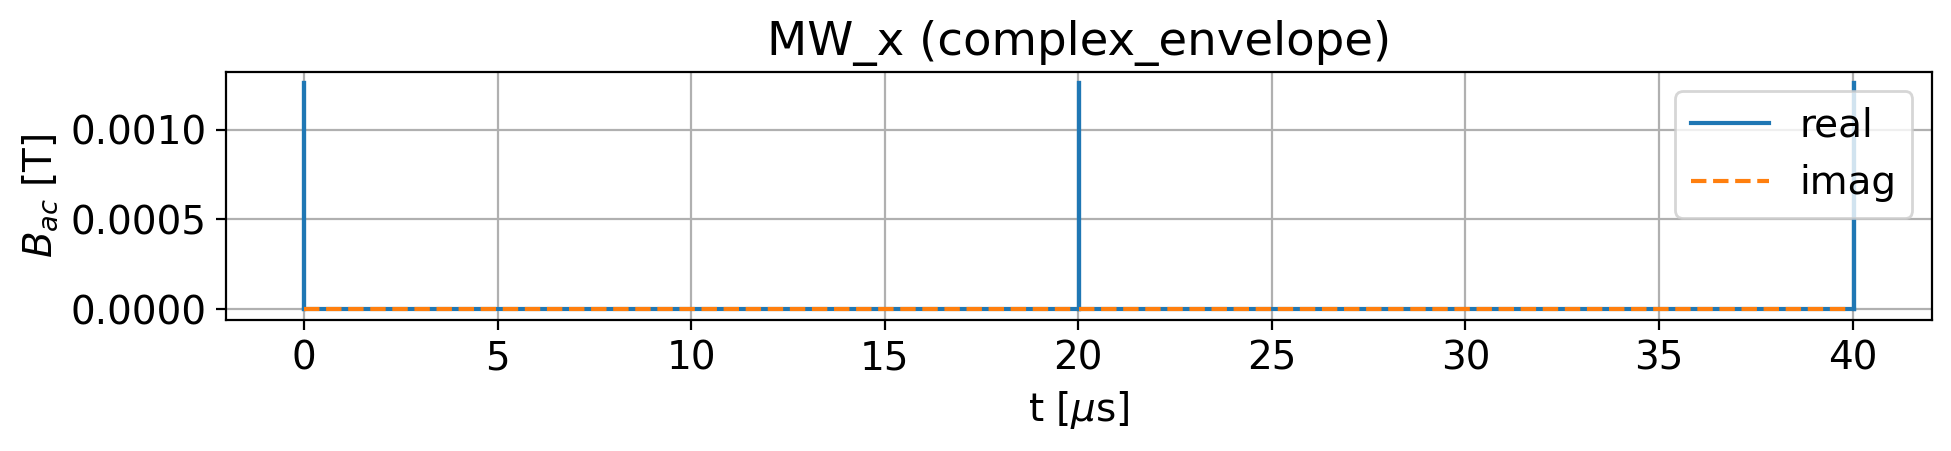

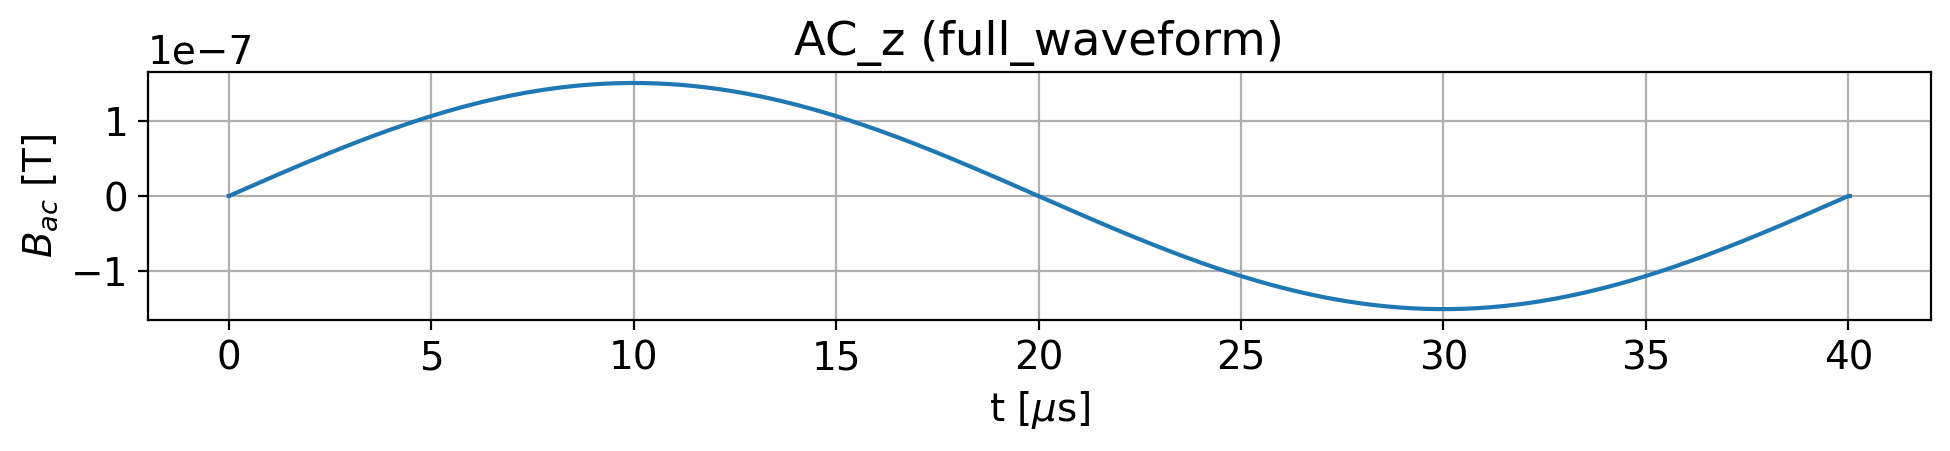

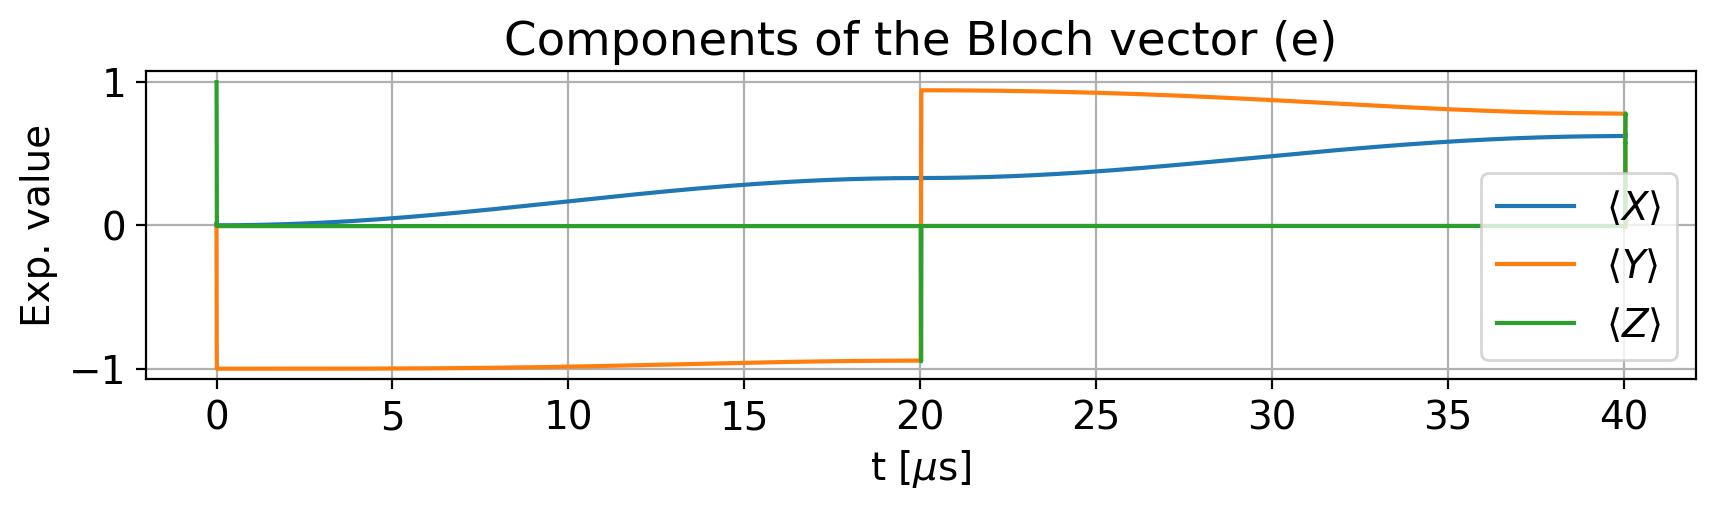

In [3]:
# Demonstration of the accumulated phase difference
model_no_n = simphony.default_nv_model(nitrogen_isotope=None,
                                  static_field_strength=0.05)
driving_field_AC = simphony.LinearDrivingField(direction = [0, 0, 1], name = 'AC_z') #the measured AC field in the z direction
model_no_n.add_driving_field(driving_field_AC)

t_period = 20.
f_ac_mhz = 1/ (2*t_period)   

tau = 20. #resonant case
#tau = 23. #offresonant case
freq_pulse = model_no_n.splitting_qubit('e')      # frequency of the pulses

#b_AC = 0.0  #no external AC field, no accumulating phase
b_AC = 0.00000015
print('Larmor frequency (MHz): ', freq_pulse)
print('AC frequency (MHz): ', f_ac_mhz)

amplitude_half_pi = model_no_n.rabi_amplitude_qubit(
                        driving_field_name='MW_x',
                        period_time = 2 * np.pi * duration1 / (np.pi / 2),
                        spin_name='e')
amplitude_pi = model_no_n.rabi_amplitude_qubit(
                        driving_field_name='MW_x',
                        period_time = 2 * np.pi * duration2 / (np.pi ),
                        spin_name='e')

model_no_n.remove_all_pulses()
model_no_n.driving_field('AC_z').add_wait(duration1)
model_no_n.driving_field('AC_z').add_rectangle_pulse(
                        amplitude=b_AC,
                        frequency=f_ac_mhz,
                        phase=-np.pi/2,
                        duration=2 * tau,
                        start = duration1)

model_no_n.driving_field('MW_x').add_rectangle_pulse(
                        amplitude=amplitude_half_pi,
                        frequency=freq_pulse,
                        phase=0,
                        duration=duration1)
model_no_n.driving_field('MW_x').add_wait(tau)
model_no_n.driving_field('MW_x').add_rectangle_pulse(
                        amplitude=amplitude_pi,
                        frequency=freq_pulse,
                        phase=0,
                        duration=duration2)
model_no_n.driving_field('MW_x').add_wait(tau)
model_no_n.driving_field('MW_x').add_rectangle_pulse(
                        amplitude=amplitude_half_pi,
                        frequency=freq_pulse,
                        phase=0,
                        duration=duration1)

model_no_n.plot_driving_fields(name = 'MW_x', function='complex_envelope')
model_no_n.plot_driving_fields(name = 'AC_z', function='full_waveform')
result = model_no_n.simulate_time_evolution(apply_noise=False)
result.initial_state = model_no_n.productstate({'e': 0})
result.plot_Bloch_vectors(frame='rotating')

### Scanning the free-evolution time

Next we wrap the sequence into a function that returns $\langle ZI \rangle$, and scan $\tau$ to
locate the resonance:

In [4]:
# Full wrapped function to simulate the electronic <Z> expectation value 
def Hahn_echo(model, wait, f_ac_mhz, B_ac_tesla, apply_noise=False, n_shots=1, ac_phase=np.pi/2):
        
    
    frequency = model.splitting_qubit('e', rest_quantum_nums={'N': 0})
    
    angle1 = np.pi / 2
    period_time1 = 2 * np.pi * duration1 / angle1
    angle2 = np.pi
    period_time2 = 2 * np.pi * duration2 / angle2
    
    amplitude1 = model.rabi_cycle_amplitude_qubit(
        driving_field_name='MW_x',
        period_time=period_time1,
        spin_name='e'
    )
    amplitude2 = model.rabi_cycle_amplitude_qubit(
        driving_field_name='MW_x',
        period_time=period_time2,
        spin_name='e'
    )
    
    model.remove_all_pulses()
    model.driving_field('AC_z').add_wait(duration1)
    model.driving_field('AC_z').add_rectangle_pulse(amplitude=B_ac_tesla,
                                                            frequency=f_ac_mhz,
                                                            phase=ac_phase,
                                                            duration=2*wait+duration2)
    model.driving_field('MW_x').add_rectangle_pulse(
        amplitude=amplitude1,
        frequency=frequency,
        phase=0,
        duration=duration1
    )

    model.driving_field('MW_x').add_wait(wait)
    model.driving_field('MW_x').add_rectangle_pulse(
        amplitude=amplitude2,
        frequency=frequency,
        phase=0,
        duration=duration2
    )
    
    model.driving_field('MW_x').add_wait(wait)
    model.driving_field('MW_x').add_rectangle_pulse(
        amplitude=amplitude1,
        frequency=frequency,
        phase=0, 
        duration=duration1
    )
    result = model.simulate_time_evolution(n_eval=2, apply_noise=apply_noise, n_shots=n_shots)
    result.initial_state = model.productstate({'e': 0,'N':0})
    expectation_value = result.expectation_value('ZI', t_idx=-1, shot='all', frame='rotating')
    
    return expectation_value[:, 0, 0]


In [5]:
t_period = 20
frequency_target = 1/(t_period*2)
B_ac =  3e-7
tau_values = np.linspace(5,80,91)

signals_hahn = np.zeros(tau_values.shape[0])
for idx,tau in enumerate(tau_values):
    model = simphony.default_nv_model(nitrogen_isotope=14, static_field_strength=B0)
    outside_field = simphony.LinearDrivingField(
        direction=[0, 0, 1],  
        name="AC_z"
    )
    model.add_driving_field(outside_field)
    signals_hahn[idx] = Hahn_echo(model, tau, f_ac_mhz=frequency_target, B_ac_tesla=B_ac,
                             apply_noise=False, n_shots=1)[0]

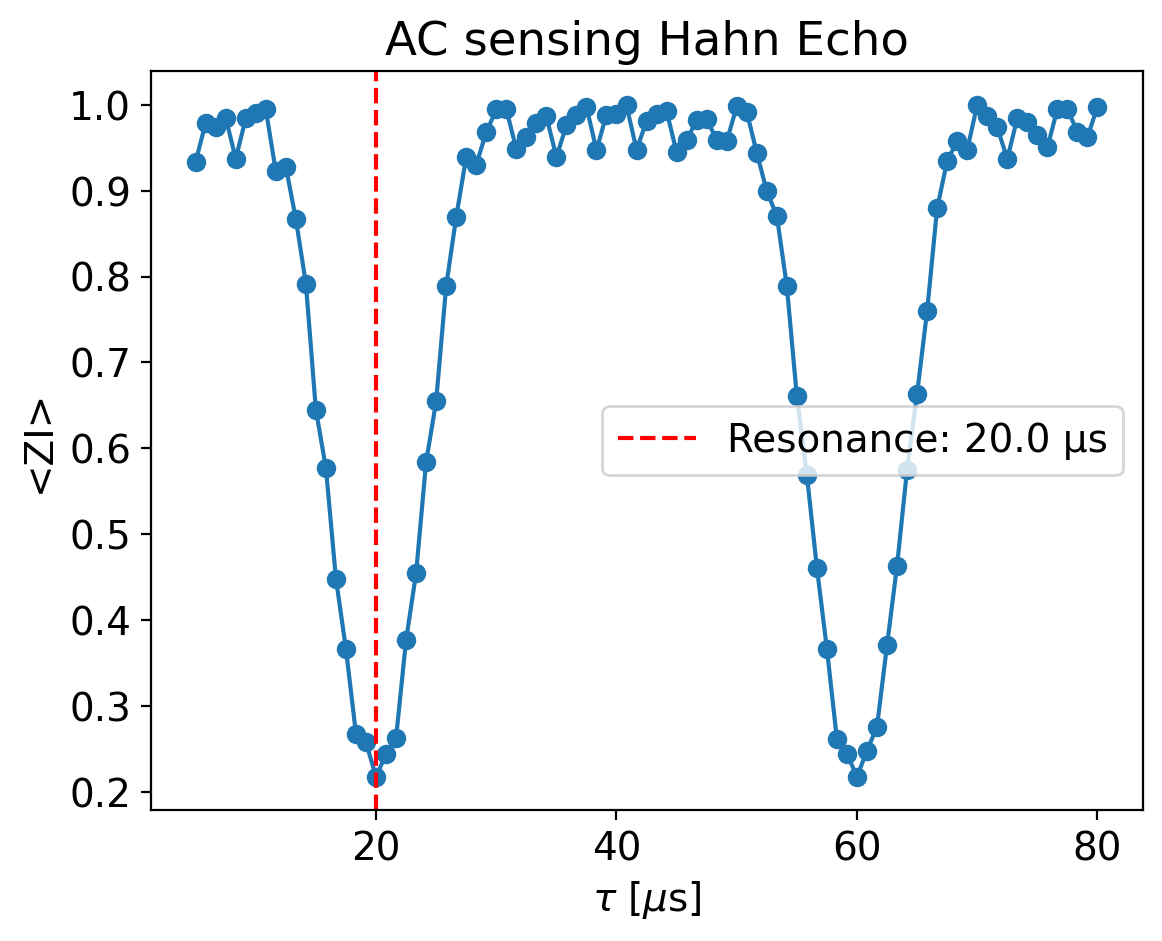

In [6]:
plt.plot(tau_values, signals_hahn, 'o-')
plt.axvline(t_period, color='r', linestyle='--', label=f'Resonance: {t_period:.1f} µs') 
plt.legend()
plt.xlabel(r"$\tau$ [$\mu$s]")
plt.ylabel("<ZI>")
plt.title("AC sensing Hahn Echo")
plt.show()

### Comparison with the analytic filter function

For an ideal sequence of **instantaneous** pulses, the accumulated phase can be written in closed
form:

$$
\Delta\Phi(\tau) = \frac{\gamma_e B_{\text{AC}}}{f_{\text{AC}}}\,\left[2\sin(2\pi f_{\text{AC}}\tau+\varphi) - \sin(4\pi f_{\text{AC}}\tau+\varphi) - \sin(\varphi)\right].
$$

We take the electron gyromagnetic ratio directly from the model
(`model.spin('e').gyromagnetic_ratio`, in MHz/T) so that the comparison is self-consistent with the
simulation:

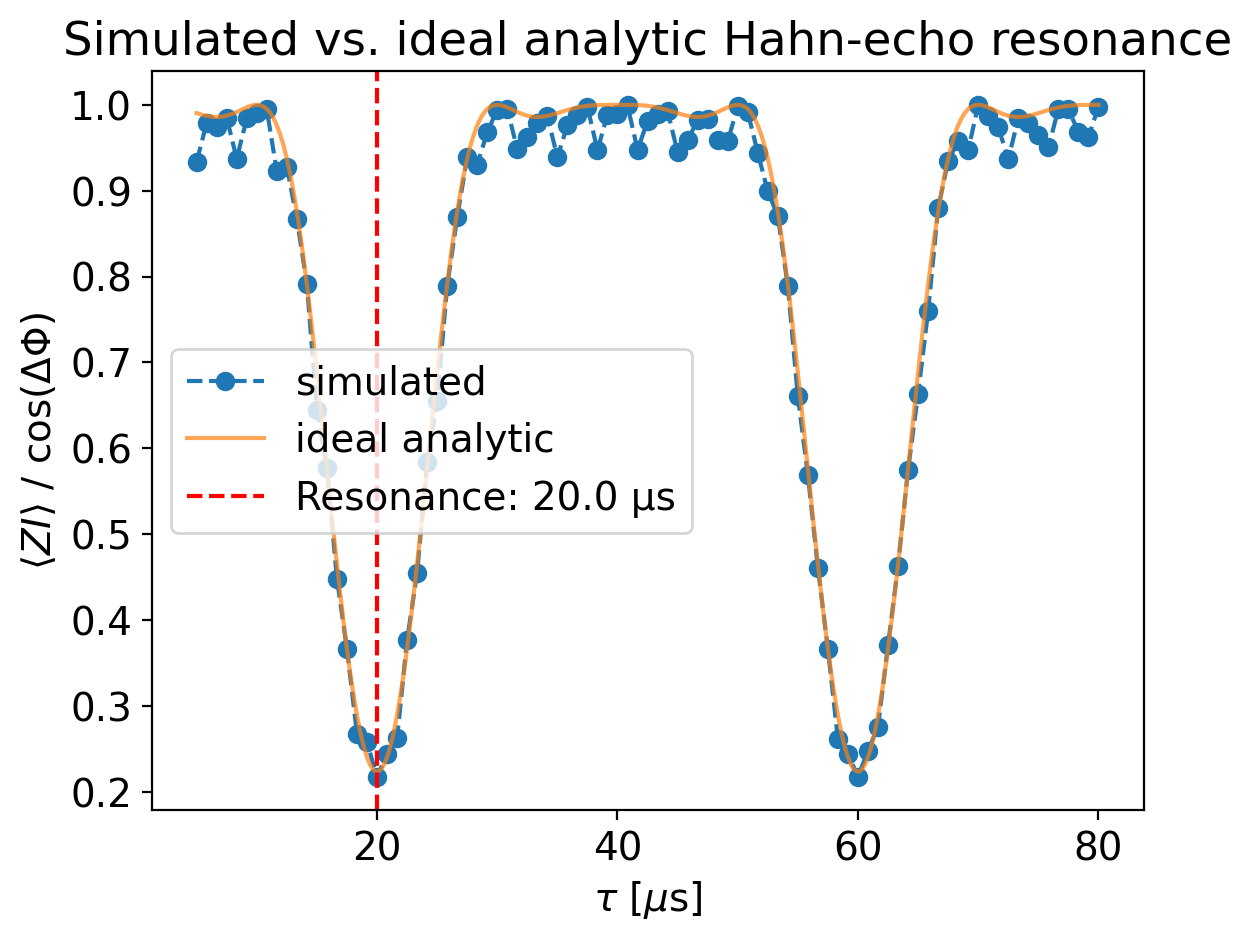

In [7]:
def delta_phi_analytic(gamma_e_mhz_per_t, B_ac_tesla, f_ac_mhz, tau, phi):
    omega = 2 * np.pi * f_ac_mhz
    return gamma_e_mhz_per_t * B_ac_tesla / f_ac_mhz * (
        2 * np.sin(omega * tau + phi) - np.sin(2 * omega * tau + phi) - np.sin(phi)
    )

gamma_e = model.spin('e').gyromagnetic_ratio  # MHz/T
tau_fine = np.linspace(tau_values[0], tau_values[-1], 400)
analytic_signal = np.cos(delta_phi_analytic(gamma_e, B_ac, frequency_target, tau_fine, np.pi / 2))

fig, ax = plt.subplots()
ax.plot(tau_values, signals_hahn, 'o--', label='simulated')
ax.plot(tau_fine, analytic_signal, '-', label='ideal analytic', alpha=0.7)
ax.axvline(t_period, color='r', linestyle='--', label=f'Resonance: {t_period:.1f} µs')
ax.set_xlabel(r"$\tau$ [$\mu$s]")
ax.set_ylabel(r"$\langle ZI \rangle$ / $\cos(\Delta\Phi)$")
ax.set_title("Simulated vs. ideal analytic Hahn-echo resonance")
ax.legend()
plt.show()

The closed form dips at the same $\tau = 20, 60, \ldots\,\mu\text{s}$ as the
simulation, which confirms the **resonance location**. The two curves do not match perfectly in
amplitude, because the analytic formula assumes instantaneous pulses and a two-level system, while
the simulation includes the finite pulse durations and the full multi-level NV Hamiltonian.

The signal falls off smoothly on either side of the resonance. Since $f_{\text{AC}}$ is held fixed
while $\tau$ is swept, the resonance condition is also met at **odd multiples** of
$\tau_{\text{res}}$. The width of the central feature is set by the total sensing time: longer
sequences give sharper resonances, which is what CPMG exploits.

### Phase scan

In practice the phase $\varphi$ of the AC field is unknown. Measuring the signal over a **grid of
$\tau$ and $\varphi$** values removes the need to know it in advance, because for every $\tau$ there
is some phase that gives a strong response. For a Hahn echo the accumulated phase is

$$
\Delta \Phi(\tau, \varphi) = 2\pi\,\gamma_e B_{\text{AC}} \left( \int_0^\tau - \int_\tau^{2\tau} \right) \cos(2\pi f_{\text{AC}} t + \varphi) \, dt .
$$

On resonance the two integrals have equal magnitude and opposite sign, giving maximal
interference at $\varphi = \pi/2$:

In [8]:
#running this cell might take a while
tau_res = 20
frequency_target = 1 / (tau_res * 2 + duration2)
B_ac = 3e-7

tau_values_hahn_hm = np.linspace(5, 35, 31) #tau values Hahn heatmap
phase_values = np.linspace(0, 2 * np.pi, 37)

heatmap = np.zeros((len(phase_values), len(tau_values_hahn_hm)))

for i, phase in enumerate(phase_values):
    for j, tau in enumerate(tau_values_hahn_hm):
        model = simphony.default_nv_model(nitrogen_isotope=14, static_field_strength=B0)
        outside_field = simphony.LinearDrivingField(direction=[0, 0, 1], name="AC_z")
        model.add_driving_field(outside_field)
        heatmap[i, j] = Hahn_echo(model, tau, f_ac_mhz=frequency_target, B_ac_tesla=B_ac,
                                   apply_noise=False, n_shots=1, ac_phase=phase)[0]

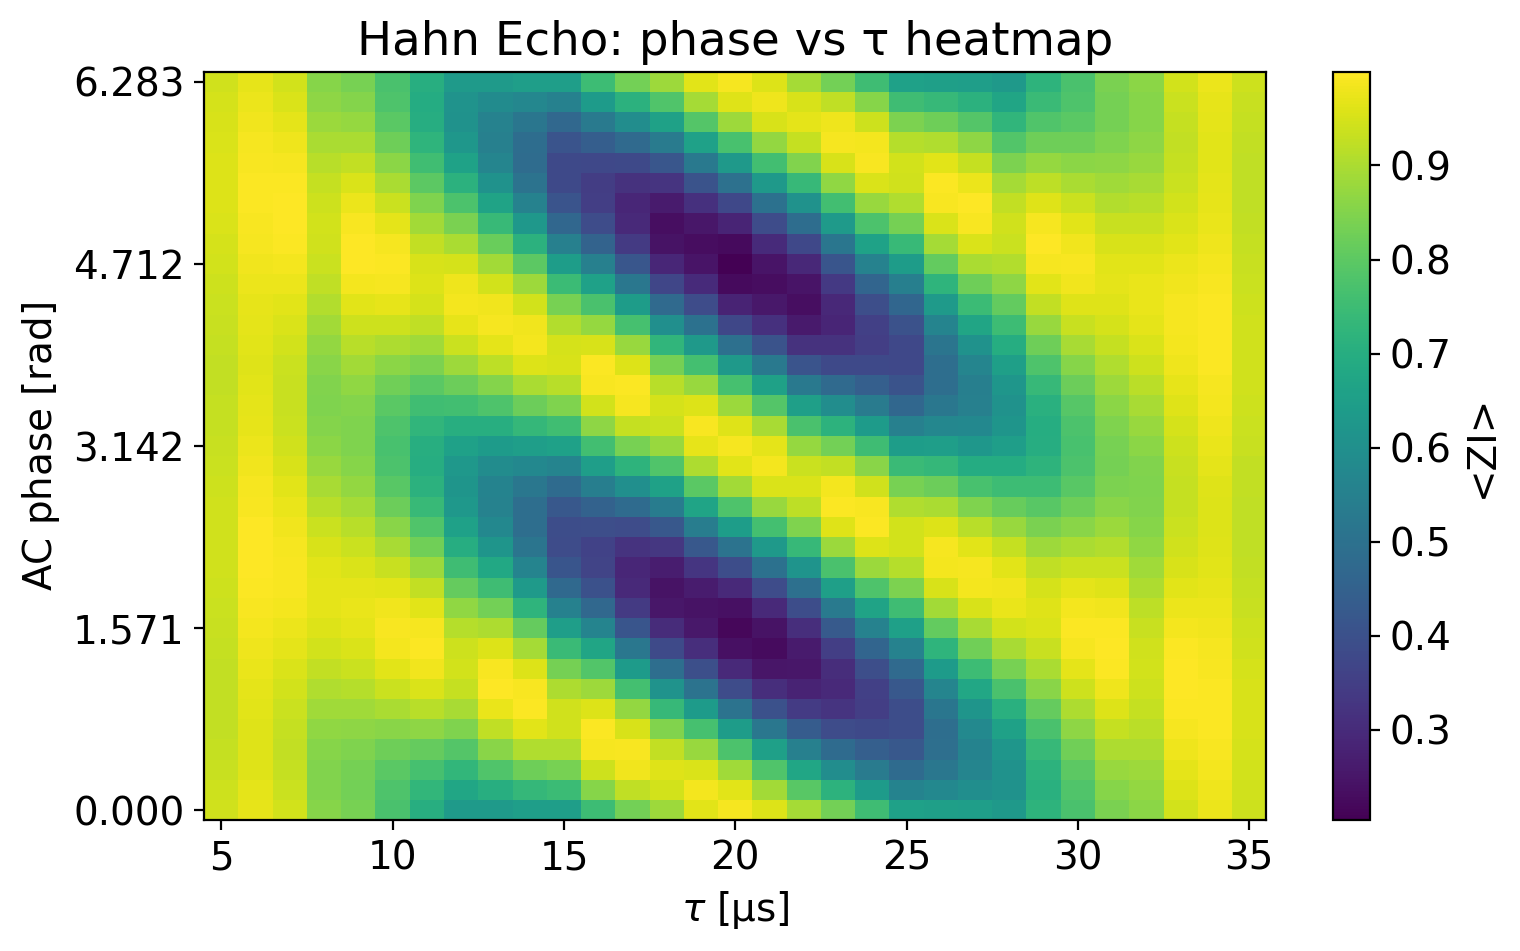

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(tau_values_hahn_hm, phase_values, heatmap, cmap='viridis', shading='auto')
fig.colorbar(im, ax=ax, label='<ZI>')
#ax.axvline(tau_res, color='k', linestyle='--', linewidth=1, label=f'Resonance τ = {tau_res} µs') # TODO: decide if to keep this line or not. 
ax.set_xlabel(r'$\tau$ [µs]')
ax.set_ylabel(r'AC phase [$\text{rad}$]')
ax.set_yticks(np.arange(0, np.pi*2.1, np.pi*0.5))
ax.set_title('Hahn Echo: phase vs τ heatmap')
plt.tight_layout()
plt.savefig('heatmap_Bac_phase_fixed.pdf')
plt.show()

Phase value at index 18: 3.14 rad


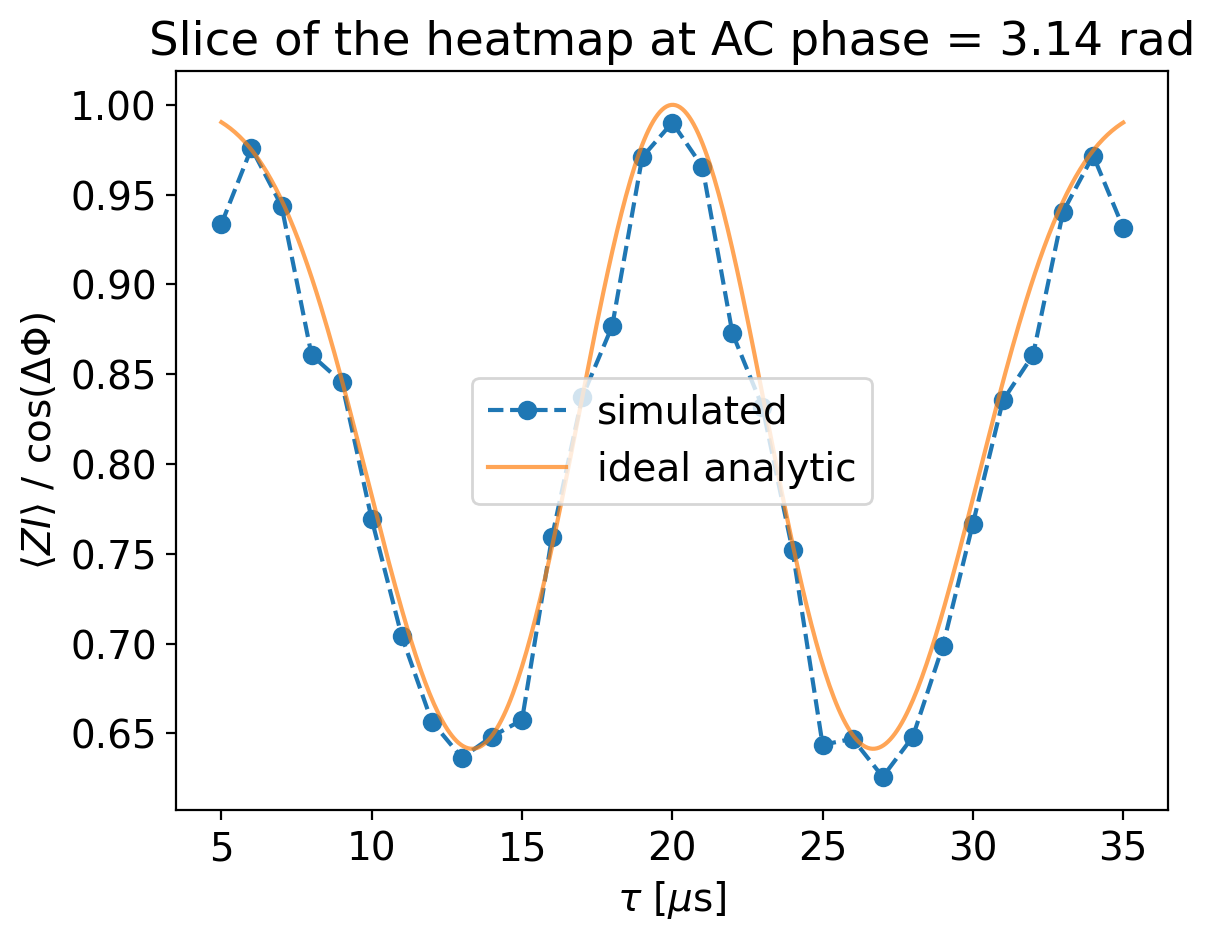

In [10]:
# Slice at a specific phase value
idx = 18
print(f"Phase value at index {idx}: {phase_values[idx]:.2f} rad")
tau_values = np.linspace(5, 35, 31)
tau_temp = heatmap[idx,:]

gamma_e = model.spin('e').gyromagnetic_ratio  # MHz/T
tau_fine = np.linspace(tau_values[0], tau_values[-1], 400)
analytic_signal = np.cos(delta_phi_analytic(gamma_e, B_ac, frequency_target, tau_fine, phase_values[idx]))


fig, ax = plt.subplots()
ax.plot(tau_values, tau_temp, 'o--', label='simulated')
ax.plot(tau_fine, analytic_signal, '-', label='ideal analytic', alpha=0.7)
#ax.axvline(t_period, color='r', linestyle='--', label=f'Resonance: {t_period:.1f} µs')
ax.set_xlabel(r"$\tau$ [$\mu$s]")
ax.set_ylabel(r"$\langle ZI \rangle$ / $\cos(\Delta\Phi)$")
ax.set_title(f"Slice of the heatmap at AC phase = {phase_values[idx]:.2f} rad")
ax.legend()
plt.show()

The heatmap shows **vertical fringes** at the resonance condition
$\tau \approx 20\,\mu$s, with a sinusoidal variation along the phase axis that reflects the
$\cos(\varphi)$ dependence of the accumulated phase.

The resonance can therefore be identified **without prior knowledge of the AC phase**, by finding
the $\tau$ that maximizes the signal amplitude across all phases.

## CPMG sequences

CPMG extends the Hahn echo by applying **several $\pi$-pulses** during the sensing time:

$$
\frac{\pi}{2}_x - (\tau - \pi_y - \tau)^n - \frac{\pi}{2}_x .
$$

The total sensing time grows to $T \approx 2n\tau$, which brings three advantages:

1. **Narrower resonances.** The filter function width scales as $\Delta f \sim 1/T$, so the
   resonance sharpens as $1/n$ and the frequency resolution improves.
2. **Better noise suppression.** Additional $\pi$-pulses refocus low-frequency noise more
   effectively, extending the coherence time.
3. **A different resonance condition.** The spacing between consecutive $\pi$-pulses is $2\tau$, so
   the resonance sits at $f_{\text{AC}} = 1/(4\tau)$.

The `CPMG` function below builds the sequence for an arbitrary number of pulses:

In [11]:
def CPMG(model, wait, f_ac_mhz, B_ac_tesla, apply_noise=False, n_shots=1, n=2,
         plot=False, n_split=250):
        
    
    has_nitrogen = 'N' in model.spin_names
    rest_quantum_nums = {'N': 0} if has_nitrogen else None
    initial_state = {'e': 0, 'N': 0} if has_nitrogen else {'e': 0}
    observable = 'ZI' if has_nitrogen else 'Z'

    frequency = model.splitting_qubit('e', rest_quantum_nums=rest_quantum_nums)
    
    angle1 = np.pi / 2
    period_time1 = 2 * np.pi * duration1 / angle1
    angle2 = np.pi
    period_time2 = 2 * np.pi * duration2 / angle2
    
    amplitude1 = model.rabi_cycle_amplitude_qubit(
        driving_field_name='MW_x',
        period_time=period_time1,
        spin_name='e'
    )
    amplitude2 = model.rabi_cycle_amplitude_qubit(
        driving_field_name='MW_x',
        period_time=period_time2,
        spin_name='e'
    )
    
    model.remove_all_pulses()
    model.driving_field('AC_z').add_wait(duration1)
    model.driving_field('AC_z').add_rectangle_pulse(amplitude=B_ac_tesla,
                                                            frequency=f_ac_mhz,
                                                            phase= ( - duration1*2*np.pi*f_ac_mhz), #phase= (np.pi/2 - (duration1+duration2+wait)*2*np.pi*f_ac_mhz),
                                                            duration=2*(n)*wait+(n-2)*duration2)
    model.driving_field('MW_x').add_rectangle_pulse(amplitude=amplitude1,
                                                    frequency=frequency,
                                                    phase=0, #rotating around the x-axis
                                                    duration=duration1)
    for i in range(n):
        model.driving_field('MW_x').add_wait(wait)
        model.driving_field('MW_x').add_rectangle_pulse(amplitude=amplitude2,
                                                    frequency=frequency,
                                                    phase=np.pi/2, #rotating around the y-axis
                                                    duration=duration2)
        if i !=n-1:
            model.driving_field('MW_x').add_wait(wait)
    model.driving_field('MW_x').add_wait(wait)
    model.driving_field('MW_x').add_rectangle_pulse(amplitude=amplitude1,
                                                    frequency=frequency,
                                                    phase=0, #rotating around the x-axis
                                                    duration=duration1)
    if plot:
        model.plot_driving_fields(function='complex_envelope', name='MW_x')
        model.plot_driving_fields(function='full_waveform', name='AC_z')
    else:
        result = model.simulate_time_evolution(n_eval=2, apply_noise=apply_noise,
                                              n_shots=n_shots, n_split=n_split)
        result.initial_state = model.productstate(initial_state)
        expectation_value = result.expectation_value(observable, t_idx=-1, shot='all',
                                                    frame='rotating')
        return expectation_value[:, 0, 0]

The corresponding idealized phase, used as a reference throughout, is the
same alternating-sign sum evaluated for $n$ pulses placed at $t_k = (2k-1)\tau$:

In [12]:
# Idealized (instantaneous-pulse) accumulated phase for the CPMG(n) sequence, matching the current
# CPMG() above.
def delta_phi_analytic_cpmg(gamma_e_mhz_per_t, B_ac_tesla, f_ac_mhz, tau, n):
    omega = 2 * np.pi * f_ac_mhz
    tau = np.asarray(tau, dtype=float)
    k = np.arange(1, n + 1)                    # pulses k = 1 .. n, at t_k = (2k-1)*tau
    t_k = np.multiply.outer(tau, 2 * k - 1)
    signs = (-1.0) ** (k + 1)
    middle_sum = 2 * np.sum(signs * np.sin(omega * t_k), axis=-1)
    T = 2 * n * tau
    edge_term = (-1) ** n * np.sin(omega * T)
    return gamma_e_mhz_per_t * B_ac_tesla / f_ac_mhz * (middle_sum + edge_term)

### Two $\pi$-pulses

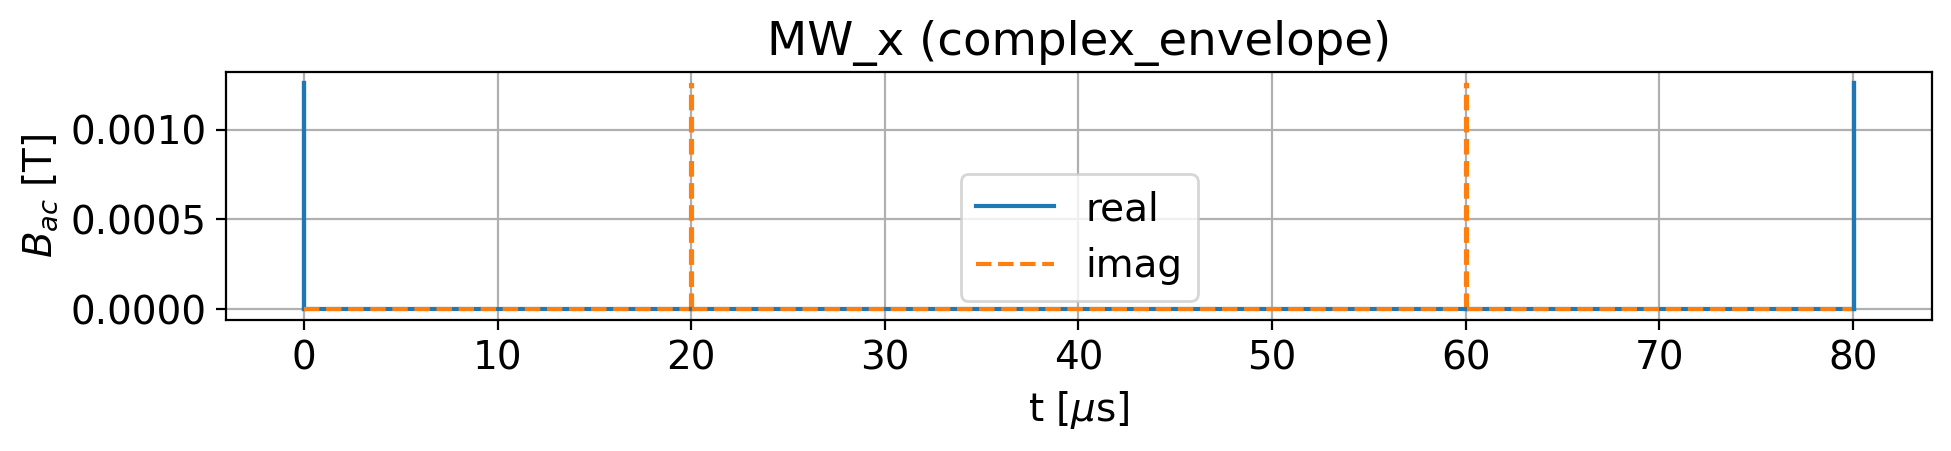

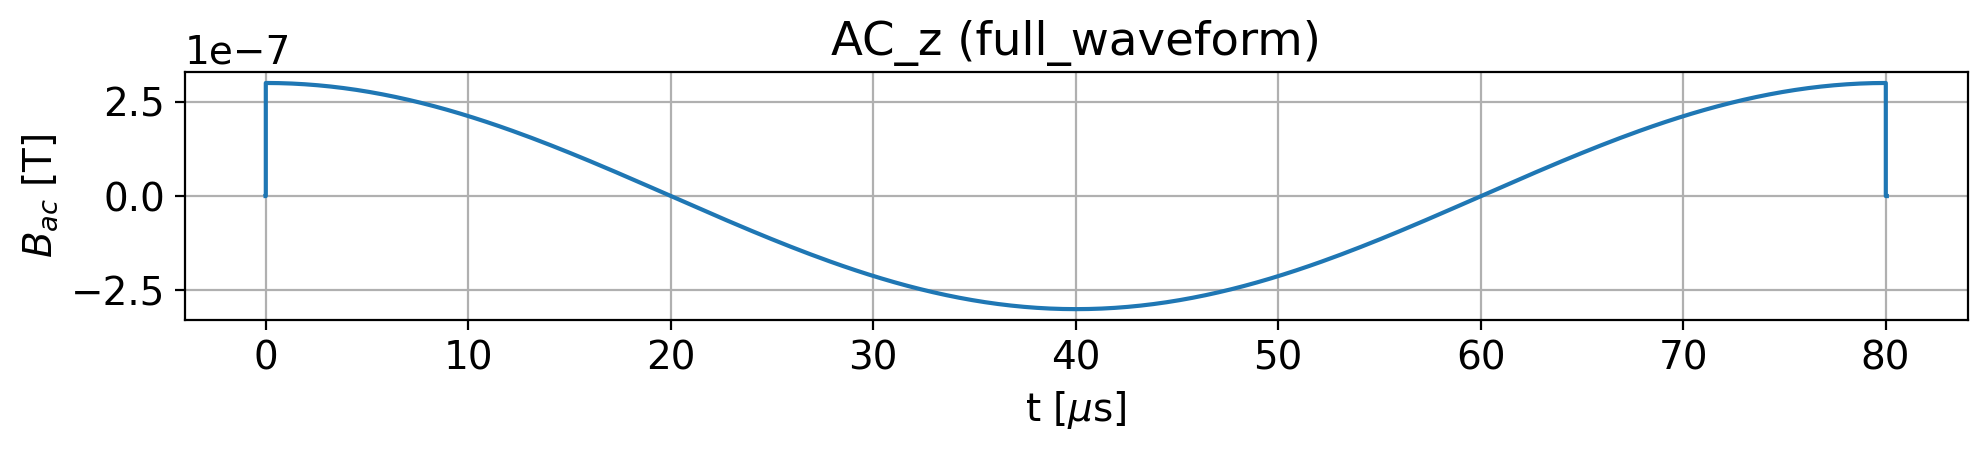

In [13]:
model_n2 = simphony.default_nv_model(nitrogen_isotope=14, static_field_strength=B0)
outside_field_n2 = simphony.LinearDrivingField(
    direction=[0, 0, 1],
    name="AC_z"
)
model_n2.add_driving_field(outside_field_n2)
tau_res_n2 = 20
frequency_target_n2 = 1/(tau_res_n2*4+duration2)
B_ac_n2 = 3e-7
tau_values_n2 = np.linspace(5,35,41)
CPMG(model_n2, tau_res_n2, f_ac_mhz=frequency_target_n2, B_ac_tesla=B_ac_n2,
                             apply_noise=False, n_shots=1, n=2, plot=True)
signals_n2 = np.zeros(tau_values_n2.shape[0])
for idx, tau in enumerate(tau_values_n2):
    signals_n2[idx] = CPMG(model_n2, tau, f_ac_mhz=frequency_target_n2, B_ac_tesla=B_ac_n2,
                             apply_noise=False, n_shots=1, n=2)[0]

Text(0.5, 1.0, 'AC sensing n = 2')

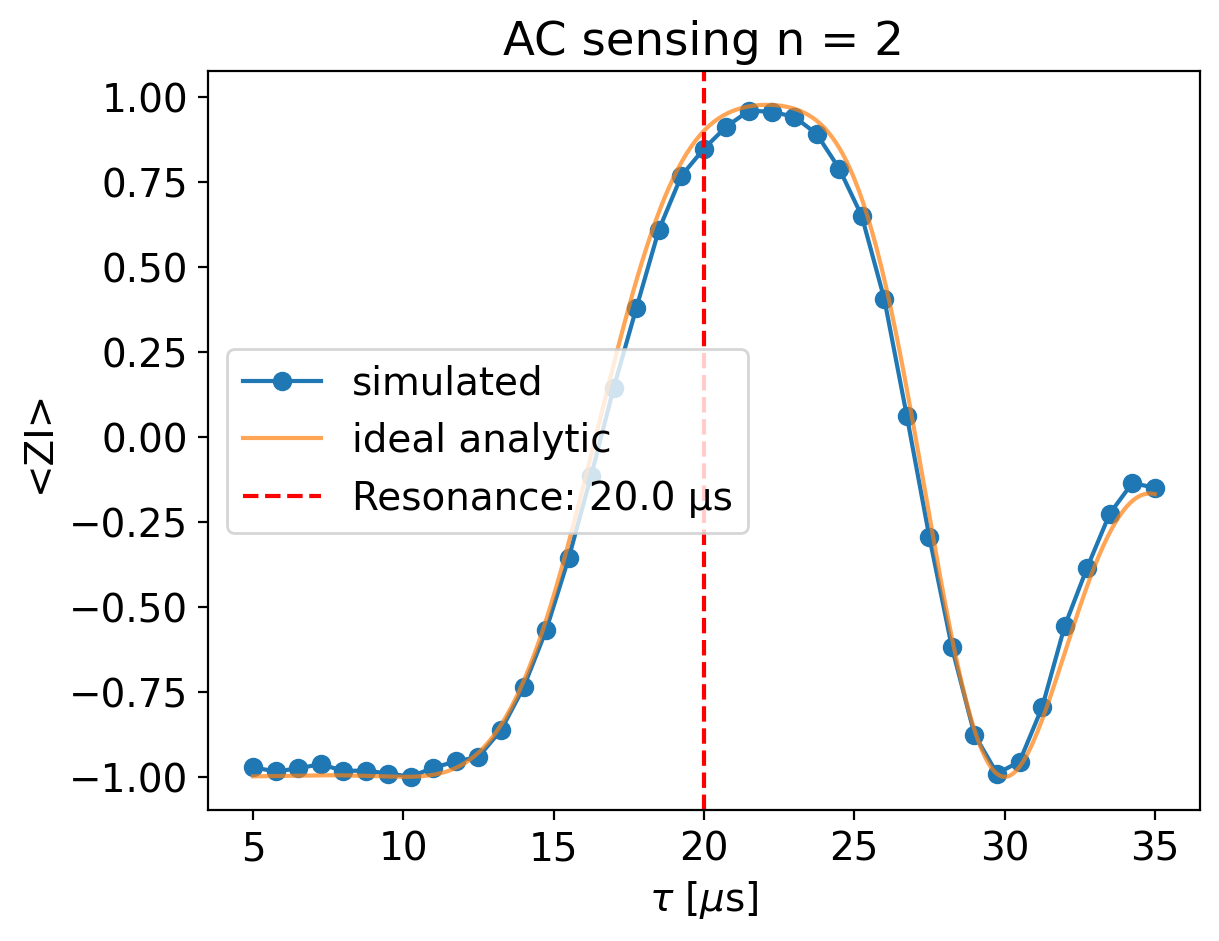

In [14]:
gamma_e_n2 = model_n2.spin('e').gyromagnetic_ratio  # MHz/T
tau_fine_n2 = np.linspace(tau_values_n2[0], tau_values_n2[-1], 400)
# minus sign: verified via an independent idealized qubit-rotation simulation (pi/2_x - pi_y(xn) - pi/2_x
# readout) that <ZI> = -cos(dPhi) for this pulse-axis sequence, for every n (not a scale effect, a fixed
# sign flip from the pulse-axis bookkeeping)
analytic_signal_n2 = -np.cos(delta_phi_analytic_cpmg(gamma_e_n2, B_ac_n2, frequency_target_n2, tau_fine_n2, n=2))

plt.plot(tau_values_n2, signals_n2, 'o-', label='simulated')
plt.plot(tau_fine_n2, analytic_signal_n2, '-', label='ideal analytic', alpha=0.7)
plt.axvline(tau_res_n2, color='r', linestyle='--', label=f'Resonance: {tau_res_n2:.1f} µs')
plt.legend()
plt.xlabel(r"$\tau$ [$\mu$s]")
plt.ylabel("<ZI>")
plt.title("AC sensing n = 2")

For $n = 2$ the resonance is not much sharper than the Hahn echo. The total
sensing time is $T \approx 4\tau + 2t_{\pi}$, only twice the Hahn echo duration for the same $\tau$,
so the **overhead of the two $\pi/2$-pulses** is still comparable to the sensing part of the
sequence.

### Three $\pi$-pulses

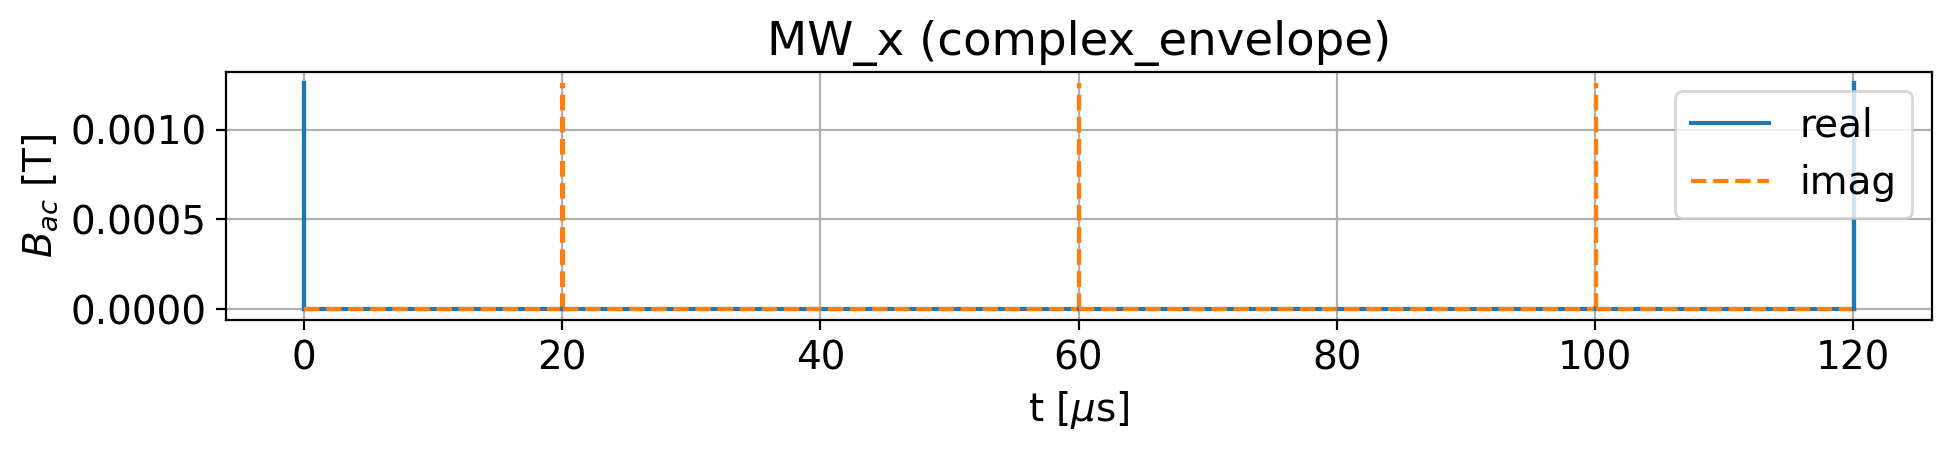

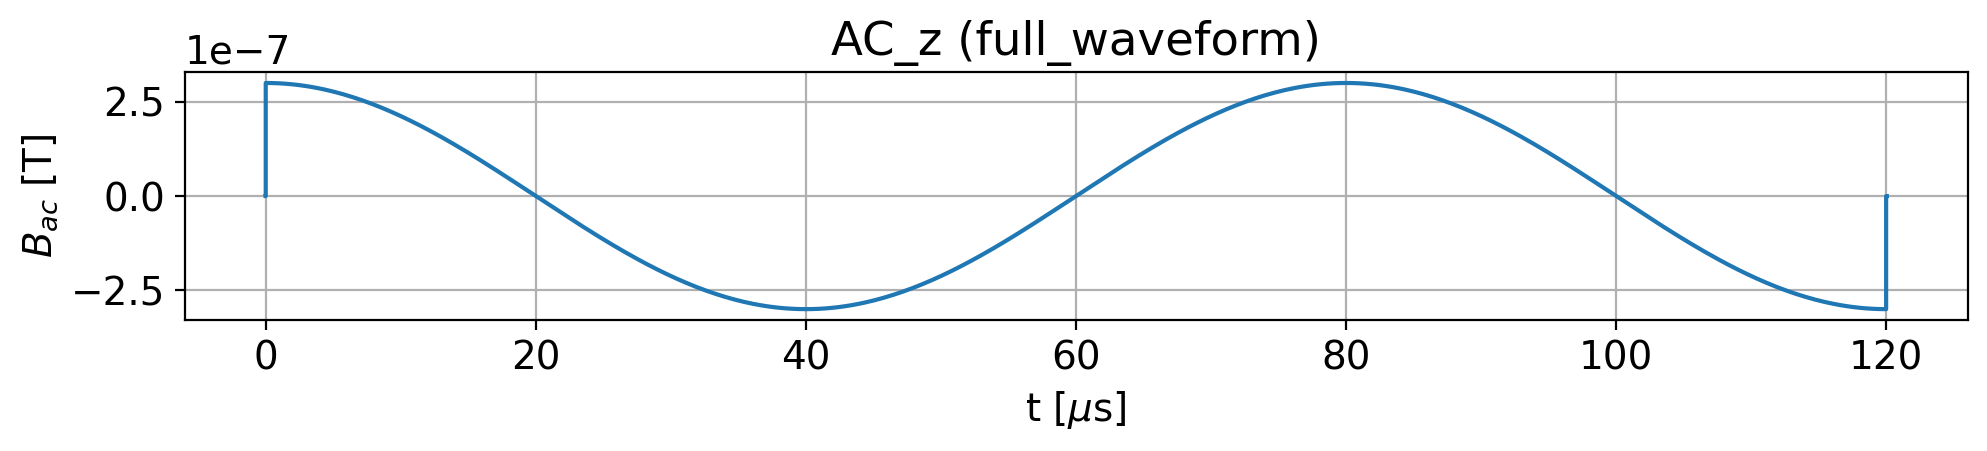

In [15]:
model_n3 = simphony.default_nv_model(nitrogen_isotope=14, static_field_strength=B0)
outside_field_n3 = simphony.LinearDrivingField(
    direction=[0, 0, 1],
    name="AC_z"
)
model_n3.add_driving_field(outside_field_n3)
tau_res_n3 = 20
frequency_target_n3 = 1/(tau_res_n3*4+duration2)
B_ac_n3 = 3e-7
tau_values_n3 = np.linspace(5,35,61)
CPMG(model_n3, tau_res_n3, f_ac_mhz=frequency_target_n3, B_ac_tesla=B_ac_n3,
                             apply_noise=False, n_shots=1, n=3, plot=True)
signals_n3 = np.zeros(tau_values_n3.shape[0])
for idx, tau in enumerate(tau_values_n3):
    signals_n3[idx] = CPMG(model_n3, tau, f_ac_mhz=frequency_target_n3, B_ac_tesla=B_ac_n3,
                             apply_noise=False, n_shots=1, n=3)[0]

Text(0.5, 1.0, 'AC sensing n = 3')

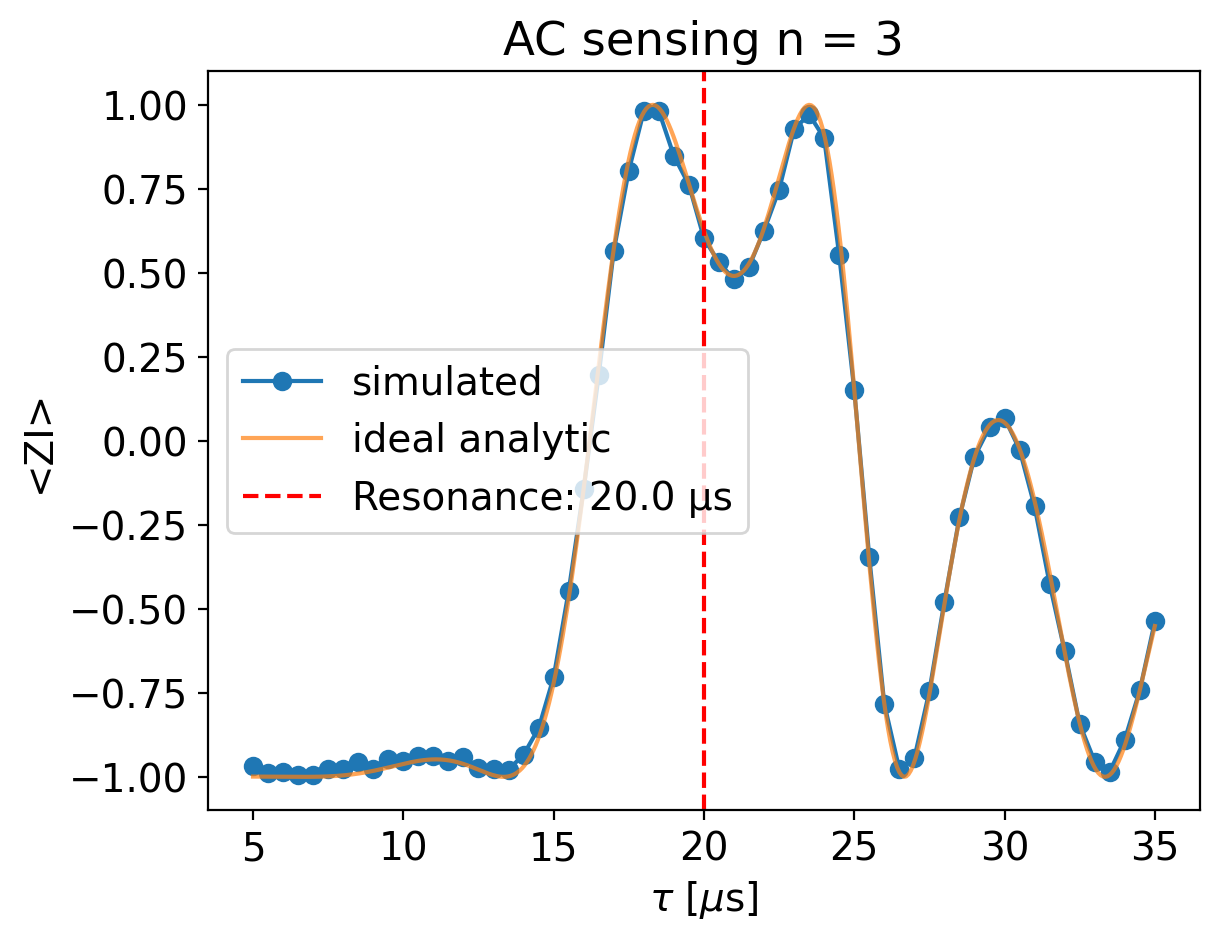

In [16]:
gamma_e_n3 = model_n3.spin('e').gyromagnetic_ratio  # MHz/T
tau_fine_n3 = np.linspace(tau_values_n3[0], tau_values_n3[-1], 400)
analytic_signal_n3 = -np.cos(delta_phi_analytic_cpmg(gamma_e_n3, B_ac_n3, frequency_target_n3, tau_fine_n3, n=3))

plt.plot(tau_values_n3, signals_n3, 'o-', label='simulated')
plt.plot(tau_fine_n3, analytic_signal_n3, '-', label='ideal analytic', alpha=0.7)
plt.axvline(tau_res_n3, color='r', linestyle='--', label=f'Resonance: {tau_res_n3:.1f} µs')
plt.legend()
plt.xlabel(r"$\tau$ [$\mu$s]")
plt.ylabel("<ZI>")
plt.title("AC sensing n = 3")

The central resonance is visibly narrower, and additional structure has appeared
on either side of it. That structure is **expected rather than spurious**: once the accumulated
phase exceeds $2\pi$, $\cos(\Delta\Phi)$ folds back on itself and the filter function develops
sidelobes. The analytic curve reproduces them, which confirms they are signal.

### Six $\pi$-pulses

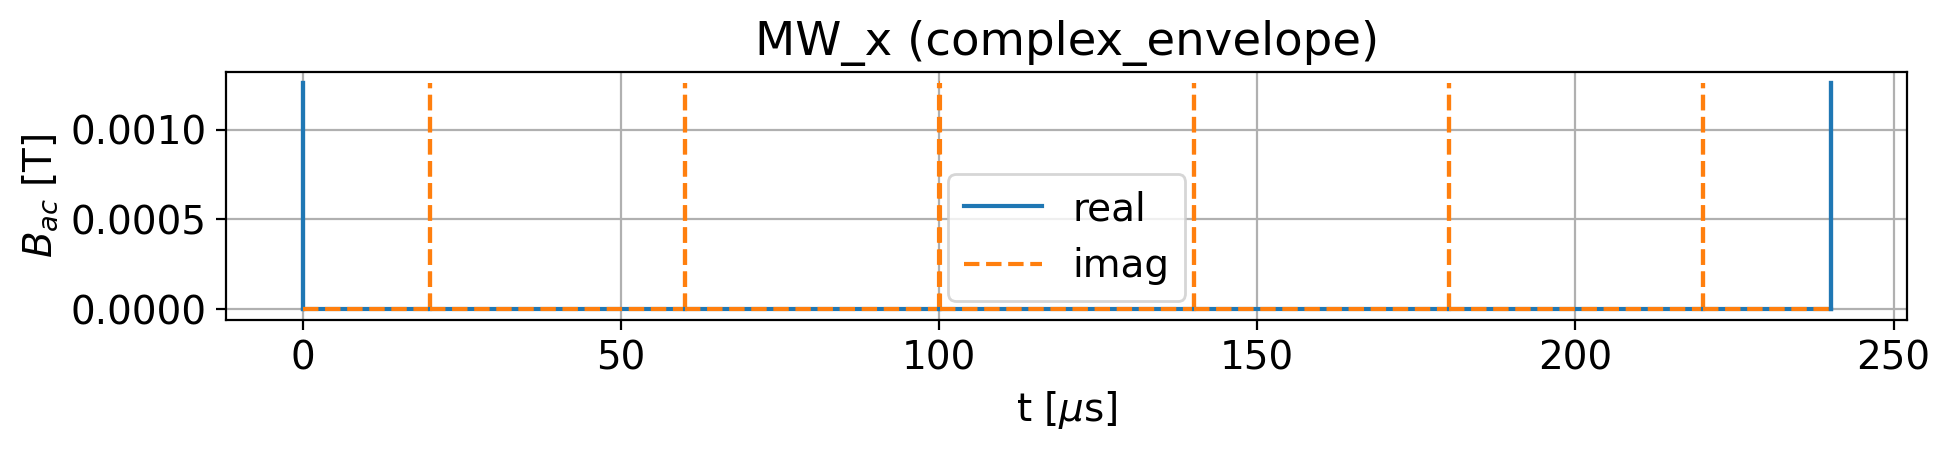

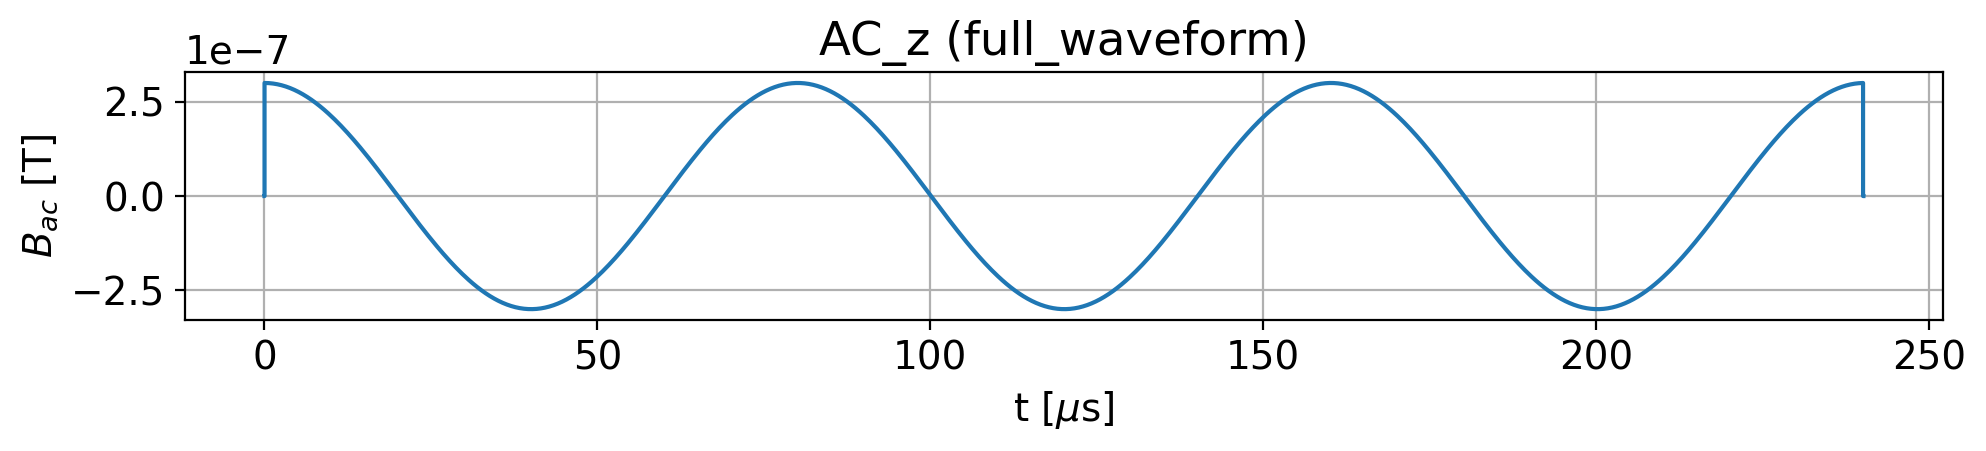

In [17]:
model_n6 = simphony.default_nv_model(nitrogen_isotope=14, static_field_strength=B0)
outside_field_n6 = simphony.LinearDrivingField(
    direction=[0, 0, 1],
    name="AC_z"
)
model_n6.add_driving_field(outside_field_n6)
tau_res_n6 = 20
frequency_target_n6 = 1/(tau_res_n6*4+4*duration2)
B_ac_n6 = 3e-7
tau_values_n6 = np.linspace(10,30,61)
CPMG(model_n6, tau_res_n6, f_ac_mhz=frequency_target_n6, B_ac_tesla=B_ac_n6,
                             apply_noise=False, n_shots=1, n=6, plot=True)
signals_n6 = np.zeros(tau_values_n6.shape[0])
for idx, tau in enumerate(tau_values_n6):
    signals_n6[idx] = CPMG(model_n6, tau, f_ac_mhz=frequency_target_n6, B_ac_tesla=B_ac_n6,
                             apply_noise=False, n_shots=1, n=6)[0]

Text(0.5, 1.0, 'AC sensing n = 6')

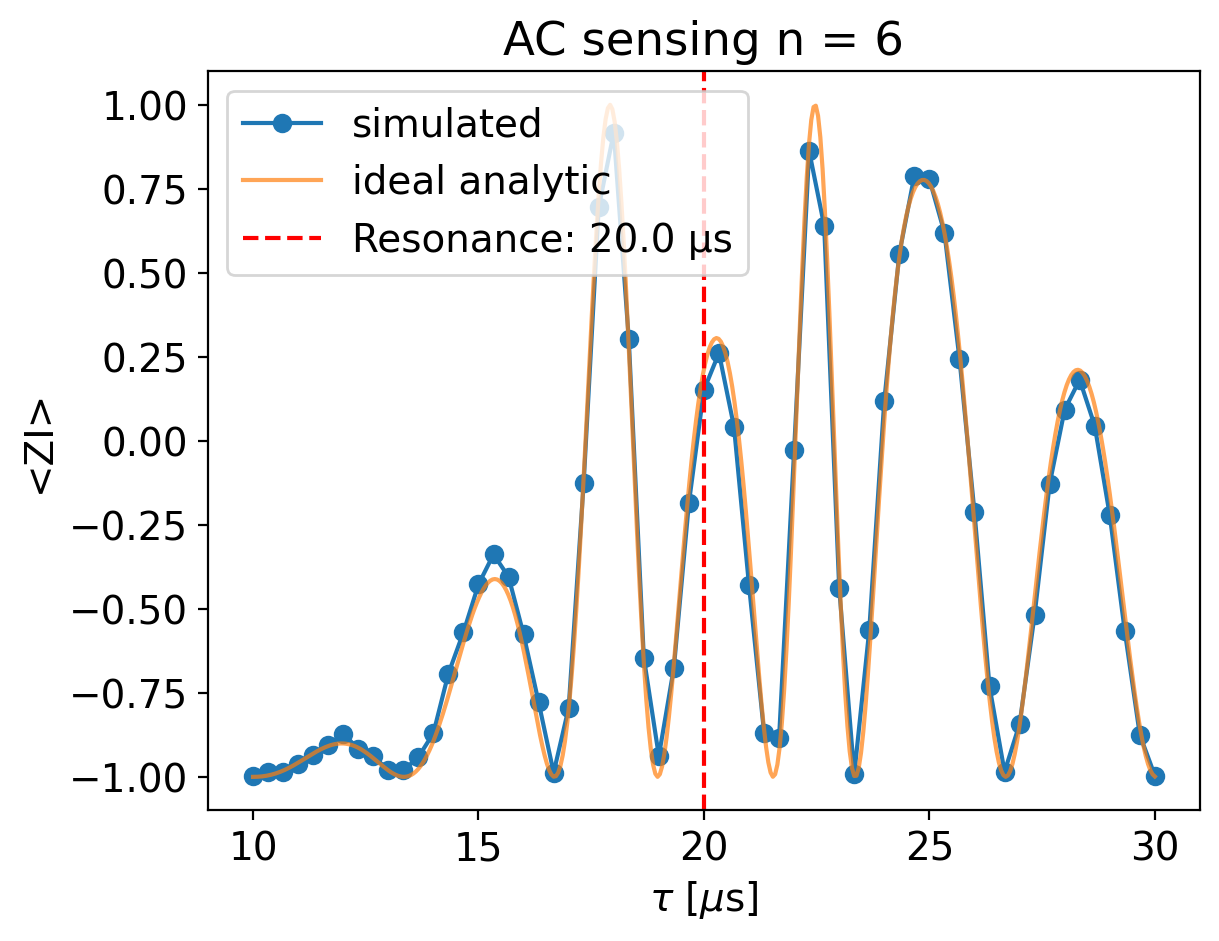

In [18]:
gamma_e_n6 = model_n6.spin('e').gyromagnetic_ratio  # MHz/T
tau_fine_n6 = np.linspace(tau_values_n6[0], tau_values_n6[-1], 400)
analytic_signal_n6 = -np.cos(delta_phi_analytic_cpmg(gamma_e_n6, B_ac_n6, frequency_target_n6, tau_fine_n6, n=6))

plt.plot(tau_values_n6, signals_n6, 'o-', label='simulated')
plt.plot(tau_fine_n6, analytic_signal_n6, '-', label='ideal analytic', alpha=0.7)
plt.axvline(tau_res_n6, color='r', linestyle='--', label=f'Resonance: {tau_res_n6:.1f} µs')
plt.legend()
plt.xlabel(r"$\tau$ [$\mu$s]")
plt.ylabel("<ZI>")
plt.title("AC sensing n = 6")

### Ten $\pi$-pulses

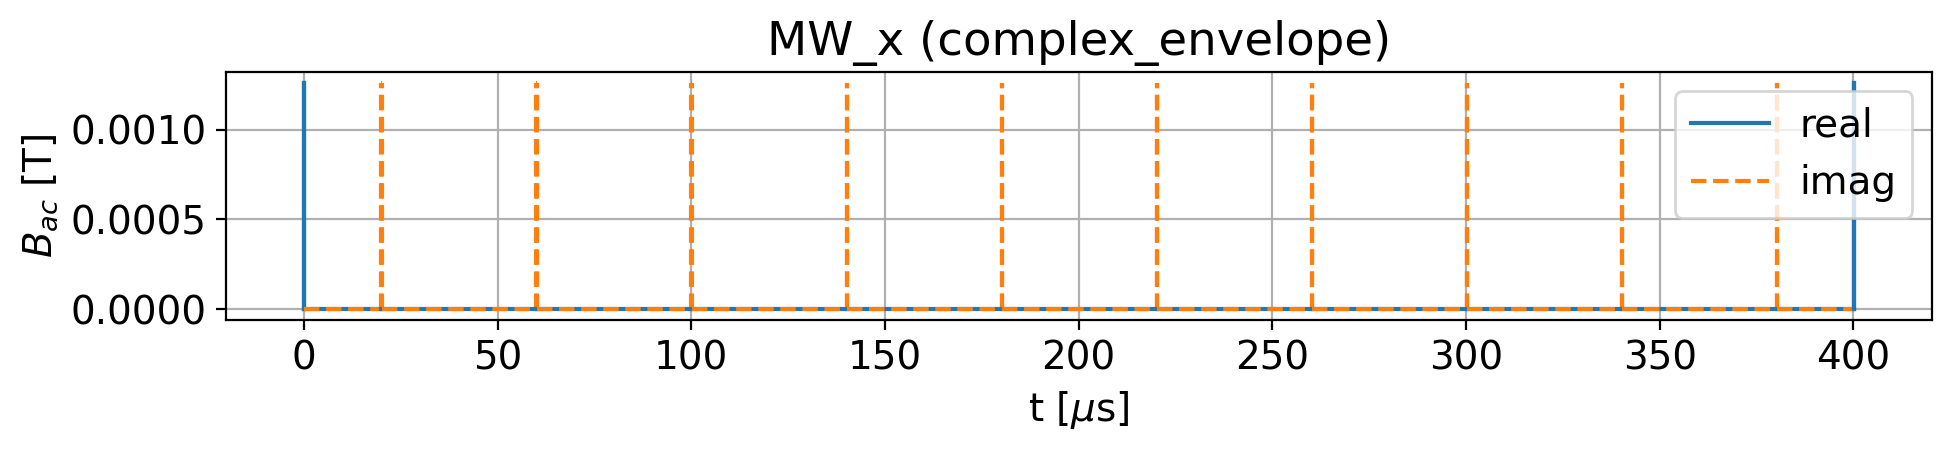

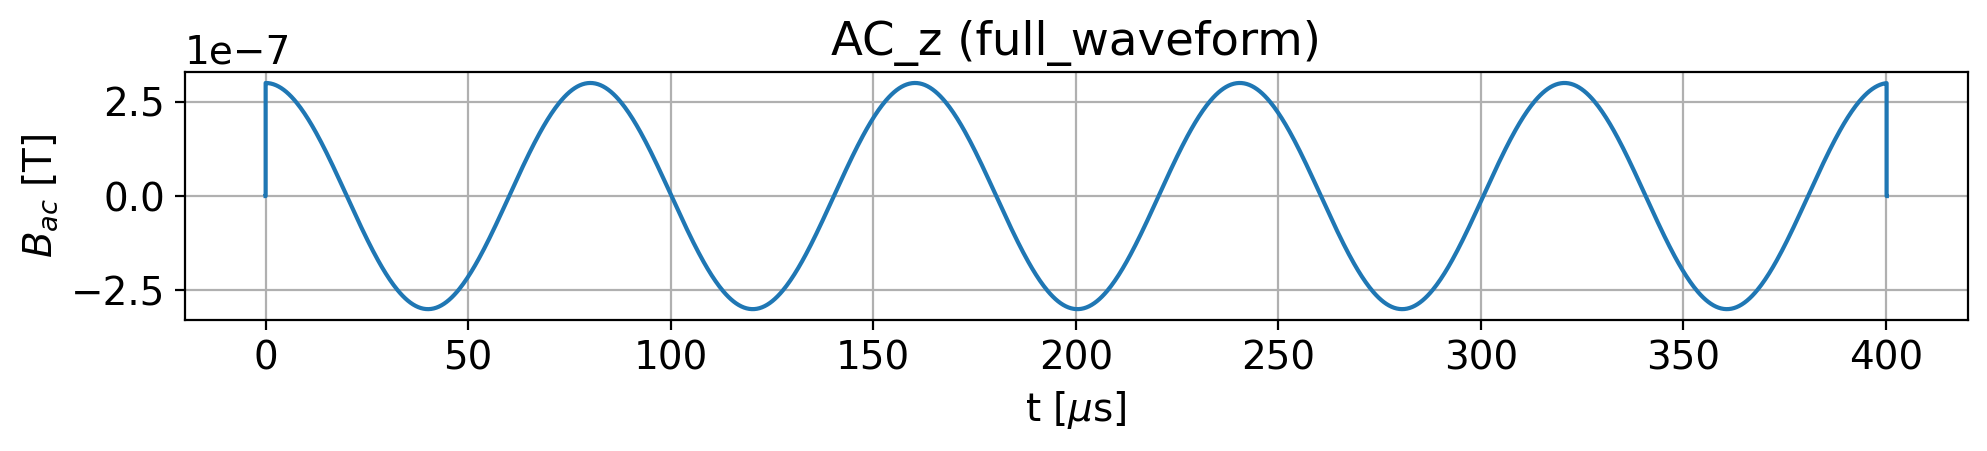

In [19]:
model_n10 = simphony.default_nv_model(nitrogen_isotope=14, static_field_strength=B0)
outside_field_n10 = simphony.LinearDrivingField(
    direction=[0, 0, 1],
    name="AC_z"
)
model_n10.add_driving_field(outside_field_n10)
tau_res_n10 = 20
frequency_target_n10 = 1/(tau_res_n10*4+8*duration2)
B_ac_n10 = 3e-7
tau_values_n10 = np.linspace(15,25,61)
CPMG(model_n10, tau_res_n10, f_ac_mhz=frequency_target_n10, B_ac_tesla=B_ac_n10,
                             apply_noise=False, n_shots=1, n=10, plot=True)
signals_n10 = np.zeros(tau_values_n10.shape[0])
for idx, tau in enumerate(tau_values_n10):
    signals_n10[idx] = CPMG(model_n10, tau, f_ac_mhz=frequency_target_n10, B_ac_tesla=B_ac_n10,
                             apply_noise=False, n_shots=1, n=10)[0]

Text(0.5, 1.0, 'AC sensing n = 10')

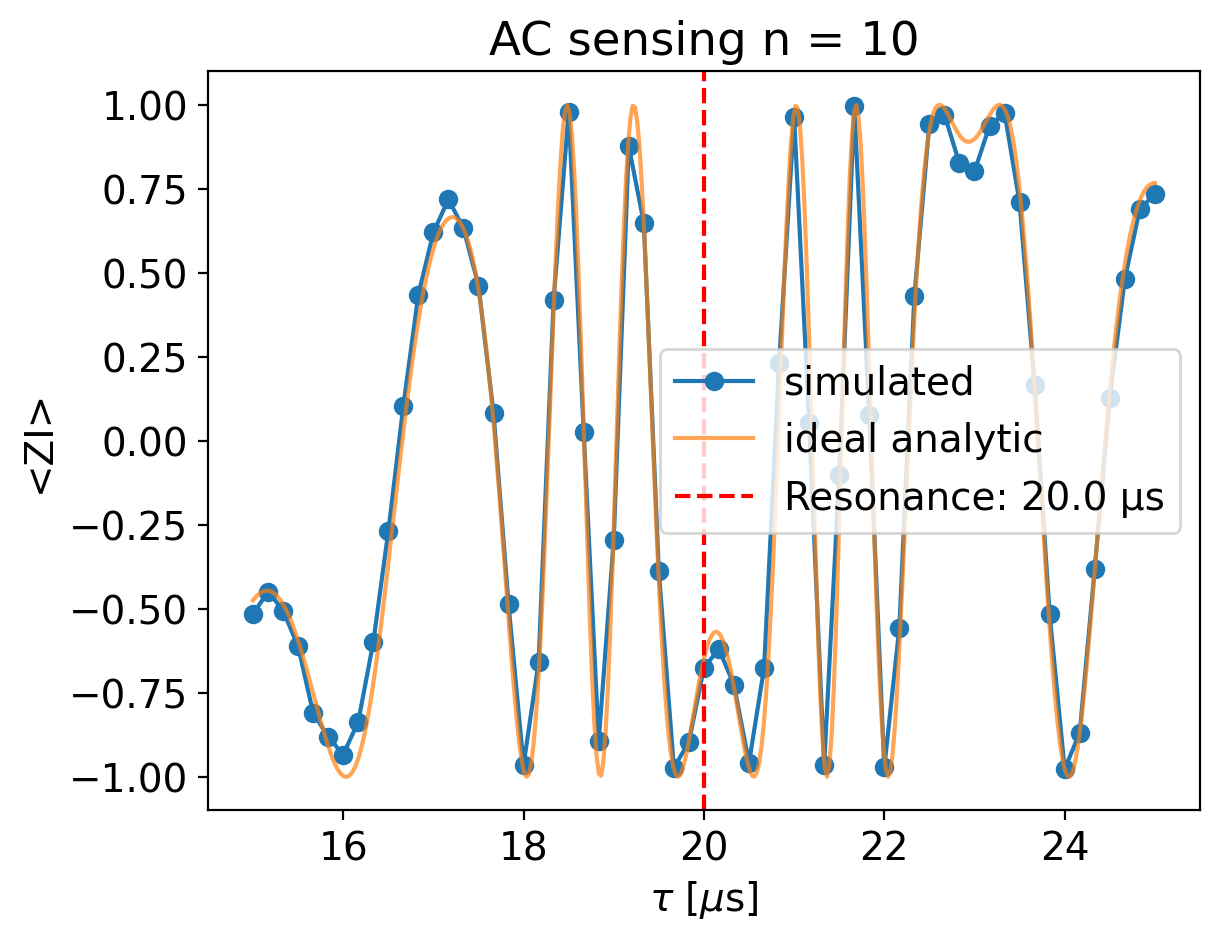

In [20]:
gamma_e_n10 = model_n10.spin('e').gyromagnetic_ratio  # MHz/T
tau_fine_n10 = np.linspace(tau_values_n10[0], tau_values_n10[-1], 400)
analytic_signal_n10 = -np.cos(delta_phi_analytic_cpmg(gamma_e_n10, B_ac_n10, frequency_target_n10, tau_fine_n10, n=10))

plt.plot(tau_values_n10, signals_n10, 'o-', label='simulated')
plt.plot(tau_fine_n10, analytic_signal_n10, '-', label='ideal analytic', alpha=0.7)
plt.axvline(tau_res_n10, color='r', linestyle='--', label=f'Resonance: {tau_res_n10:.1f} µs')
plt.legend()
plt.xlabel(r"$\tau$ [$\mu$s]")
plt.ylabel("<ZI>")
plt.title("AC sensing n = 10")

### What the scans show

Three observations follow from the four scans above.

- **The resonance sharpens with $n$.** The central feature narrows steadily from $n = 2$ to
  $n = 10$, consistent with a sensing time $T \approx 2n\tau$ and a filter function that narrows as
  $1/n$. The next section measures this.
- **The sidelobes are real signal.** The oscillations flanking the resonance become more numerous
  with $n$, and the ideal instantaneous-pulse formula reproduces their position and shape at every
  $n$. They come from the filter function folding through $\cos(\Delta\Phi)$.
- **The agreement is good but not exact.** At $n = 6$ and $n = 10$ some simulated extrema fall a few
  percent short of the analytic curve, which is the order of magnitude expected from the $^{14}$N
  hyperfine coupling that the two-level formula ignores.

## Spectral resolution

The practical value of CPMG is **spectral resolution**, quantified by the full width at half maximum
of the resonance. The Fourier limit sets

$$
\Delta f \approx \frac{1}{T},
$$

with $T \approx 2n\tau$ for CPMG($n$), so the expected trend is $\text{FWHM} \propto 1/n$.

Two points need care before measuring it.

**The lineshape must not be folded.** The signal is $-\cos(\Delta\Phi)$, and once
$|\Delta\Phi|$ at resonance passes $\pi$ the cosine folds back, breaking the $\tau$ scan into
several lobes of comparable size — at which point the width of "the" resonance is not defined.
Scaling the AC amplitude as $1/n$ holds the **peak phase response fixed**, so every sequence
produces a single lobe with the same contrast and the widths are directly comparable.

**The width must be extracted from the lineshape itself.** The helper below locates the central
extremum, takes a baseline from the scan wings, and returns the separation of the two linearly
interpolated **half-maximum crossings**:

In [21]:
def resonance_fwhm(taus, signal, tau_res, search_frac=0.35):
    """FWHM of the central resonance, from linear-interpolated half-maximum crossings.

    The central feature is located as the extremum nearest ``tau_res``, the baseline is taken
    from the scan wings, and the width is the separation of the two points where the curve
    crosses half of (peak - baseline).

    Args:
        taus: Scanned free-evolution times (in us), monotonically increasing.
        signal: Corresponding <ZI> values.
        tau_res: Nominal resonance position, used to decide which extremum is the resonance.
        search_frac: Fraction of the scan span around ``tau_res`` searched for the extremum.

    Returns:
        Dict with the fwhm and the intermediate quantities needed to plot the measurement.
        ``fwhm`` is ``None`` if the scan window ends before the curve crosses the half level.
    """

    t = np.asarray(taus, dtype=float)
    s = np.asarray(signal, dtype=float)

    i_res = np.argmin(np.abs(t - tau_res))
    upward = s[i_res] > np.median(s)      # CPMG gives a peak here, the Hahn echo a dip
    ss = s if upward else -s

    near = np.abs(t - tau_res) <= search_frac * (t[-1] - t[0])
    i_peak = np.flatnonzero(near)[np.argmax(ss[near])]

    baseline = np.percentile(ss, 10)
    half = baseline + 0.5 * (ss[i_peak] - baseline)

    def crossing(indices):
        """First half-level crossing walking away from the peak; None if the scan ends first."""
        prev = i_peak
        for i in indices:
            if ss[i] < half:
                return t[prev] + (half - ss[prev]) * (t[i] - t[prev]) / (ss[i] - ss[prev])
            prev = i
        return None

    t_left = crossing(range(i_peak - 1, -1, -1))
    t_right = crossing(range(i_peak + 1, len(t)))

    fwhm = None if (t_left is None or t_right is None) else t_right - t_left
    sign = 1.0 if upward else -1.0

    return {'fwhm': fwhm, 'tau_left': t_left, 'tau_right': t_right,
            'half_level': sign * half, 'baseline': sign * baseline,
            'peak_tau': t[i_peak], 'peak_val': s[i_peak]}

Choosing the AC amplitude for each $n$ so that the peak phase response is
$0.71\pi$ keeps all four sequences in the single-lobe regime:

In [22]:
# To compare linewidths across n we must keep every sequence in the single-lobe regime: once the
# accumulated phase at resonance passes pi, cos(dPhi) folds back and the tau scan develops several
# lobes of comparable size, at which point "the width of the resonance" is not defined. Scaling the
# AC amplitude as 1/n holds the peak phase response fixed, so all four sequences have the same
# contrast and the comparison is apples-to-apples.
def peak_phase(B_ac_tesla, f_ac_mhz, n, tau_res=20.0):
    """Accumulated phase at resonance for the ideal (instantaneous-pulse) CPMG(n) sequence."""
    return abs(delta_phi_analytic_cpmg(gamma_e_n6, B_ac_tesla, f_ac_mhz, tau_res, n=n))


f_ac_fwhm = 1 / (20 * 4 + 5 * duration2)
target_phase = 2.24                      # rad = 0.71 pi: single lobe, near-full contrast

# (n, tau window) -- windows sized to about 1.6x the expected width
fwhm_windows = {2: (11.8, 28.2), 3: (14.5, 25.5), 6: (17.2, 22.8), 10: (18.3, 21.7)}
fwhm_cfg = []
for n, window in fwhm_windows.items():
    B_ac_n = 1e-7 * target_phase / peak_phase(1e-7, f_ac_fwhm, n)
    fwhm_cfg.append((n, B_ac_n, window))

print(f'{"n":>3s}{"B_ac [T]":>13s}{"peak phase":>13s}{"tau window":>18s}')
for n, B_ac_n, window in fwhm_cfg:
    print(f'{n:3d}{B_ac_n:13.3e}{peak_phase(B_ac_n, f_ac_fwhm, n) / np.pi:11.2f} pi'
          f'{str(window):>18s}')

  n     B_ac [T]   peak phase        tau window
  2    2.499e-07       0.71 pi      (11.8, 28.2)
  3    1.666e-07       0.71 pi      (14.5, 25.5)
  6    8.330e-08       0.71 pi      (17.2, 22.8)
 10    4.999e-08       0.71 pi      (18.3, 21.7)


Now run the four scans:

In [23]:
# The four linewidth scans. Each uses its own AC amplitude and window from the cell above.
fwhm_scans = {}
for n, B_ac_n, window in fwhm_cfg:
    taus = np.linspace(window[0], window[1], 61)
    signal = np.zeros_like(taus)
    for idx, tau in enumerate(taus):
        model = simphony.default_nv_model(nitrogen_isotope=14, static_field_strength=B0)
        model.add_driving_field(simphony.LinearDrivingField(direction=[0, 0, 1], name='AC_z'))
        signal[idx] = CPMG(model, float(tau), f_ac_mhz=f_ac_fwhm, B_ac_tesla=B_ac_n,
                           apply_noise=False, n_shots=1, n=n)[0]
    fwhm_scans[n] = (taus, signal)
    print(f'n = {n:2d} done   range = [{signal.min():+.3f}, {signal.max():+.3f}]')

n =  2 done   range = [-0.985, +0.728]


n =  3 done   range = [-0.943, +0.689]


n =  6 done   range = [-0.962, +0.595]


n = 10 done   range = [-0.954, +0.591]


The construction is plotted alongside each scan, so the measurement can be
checked by eye:

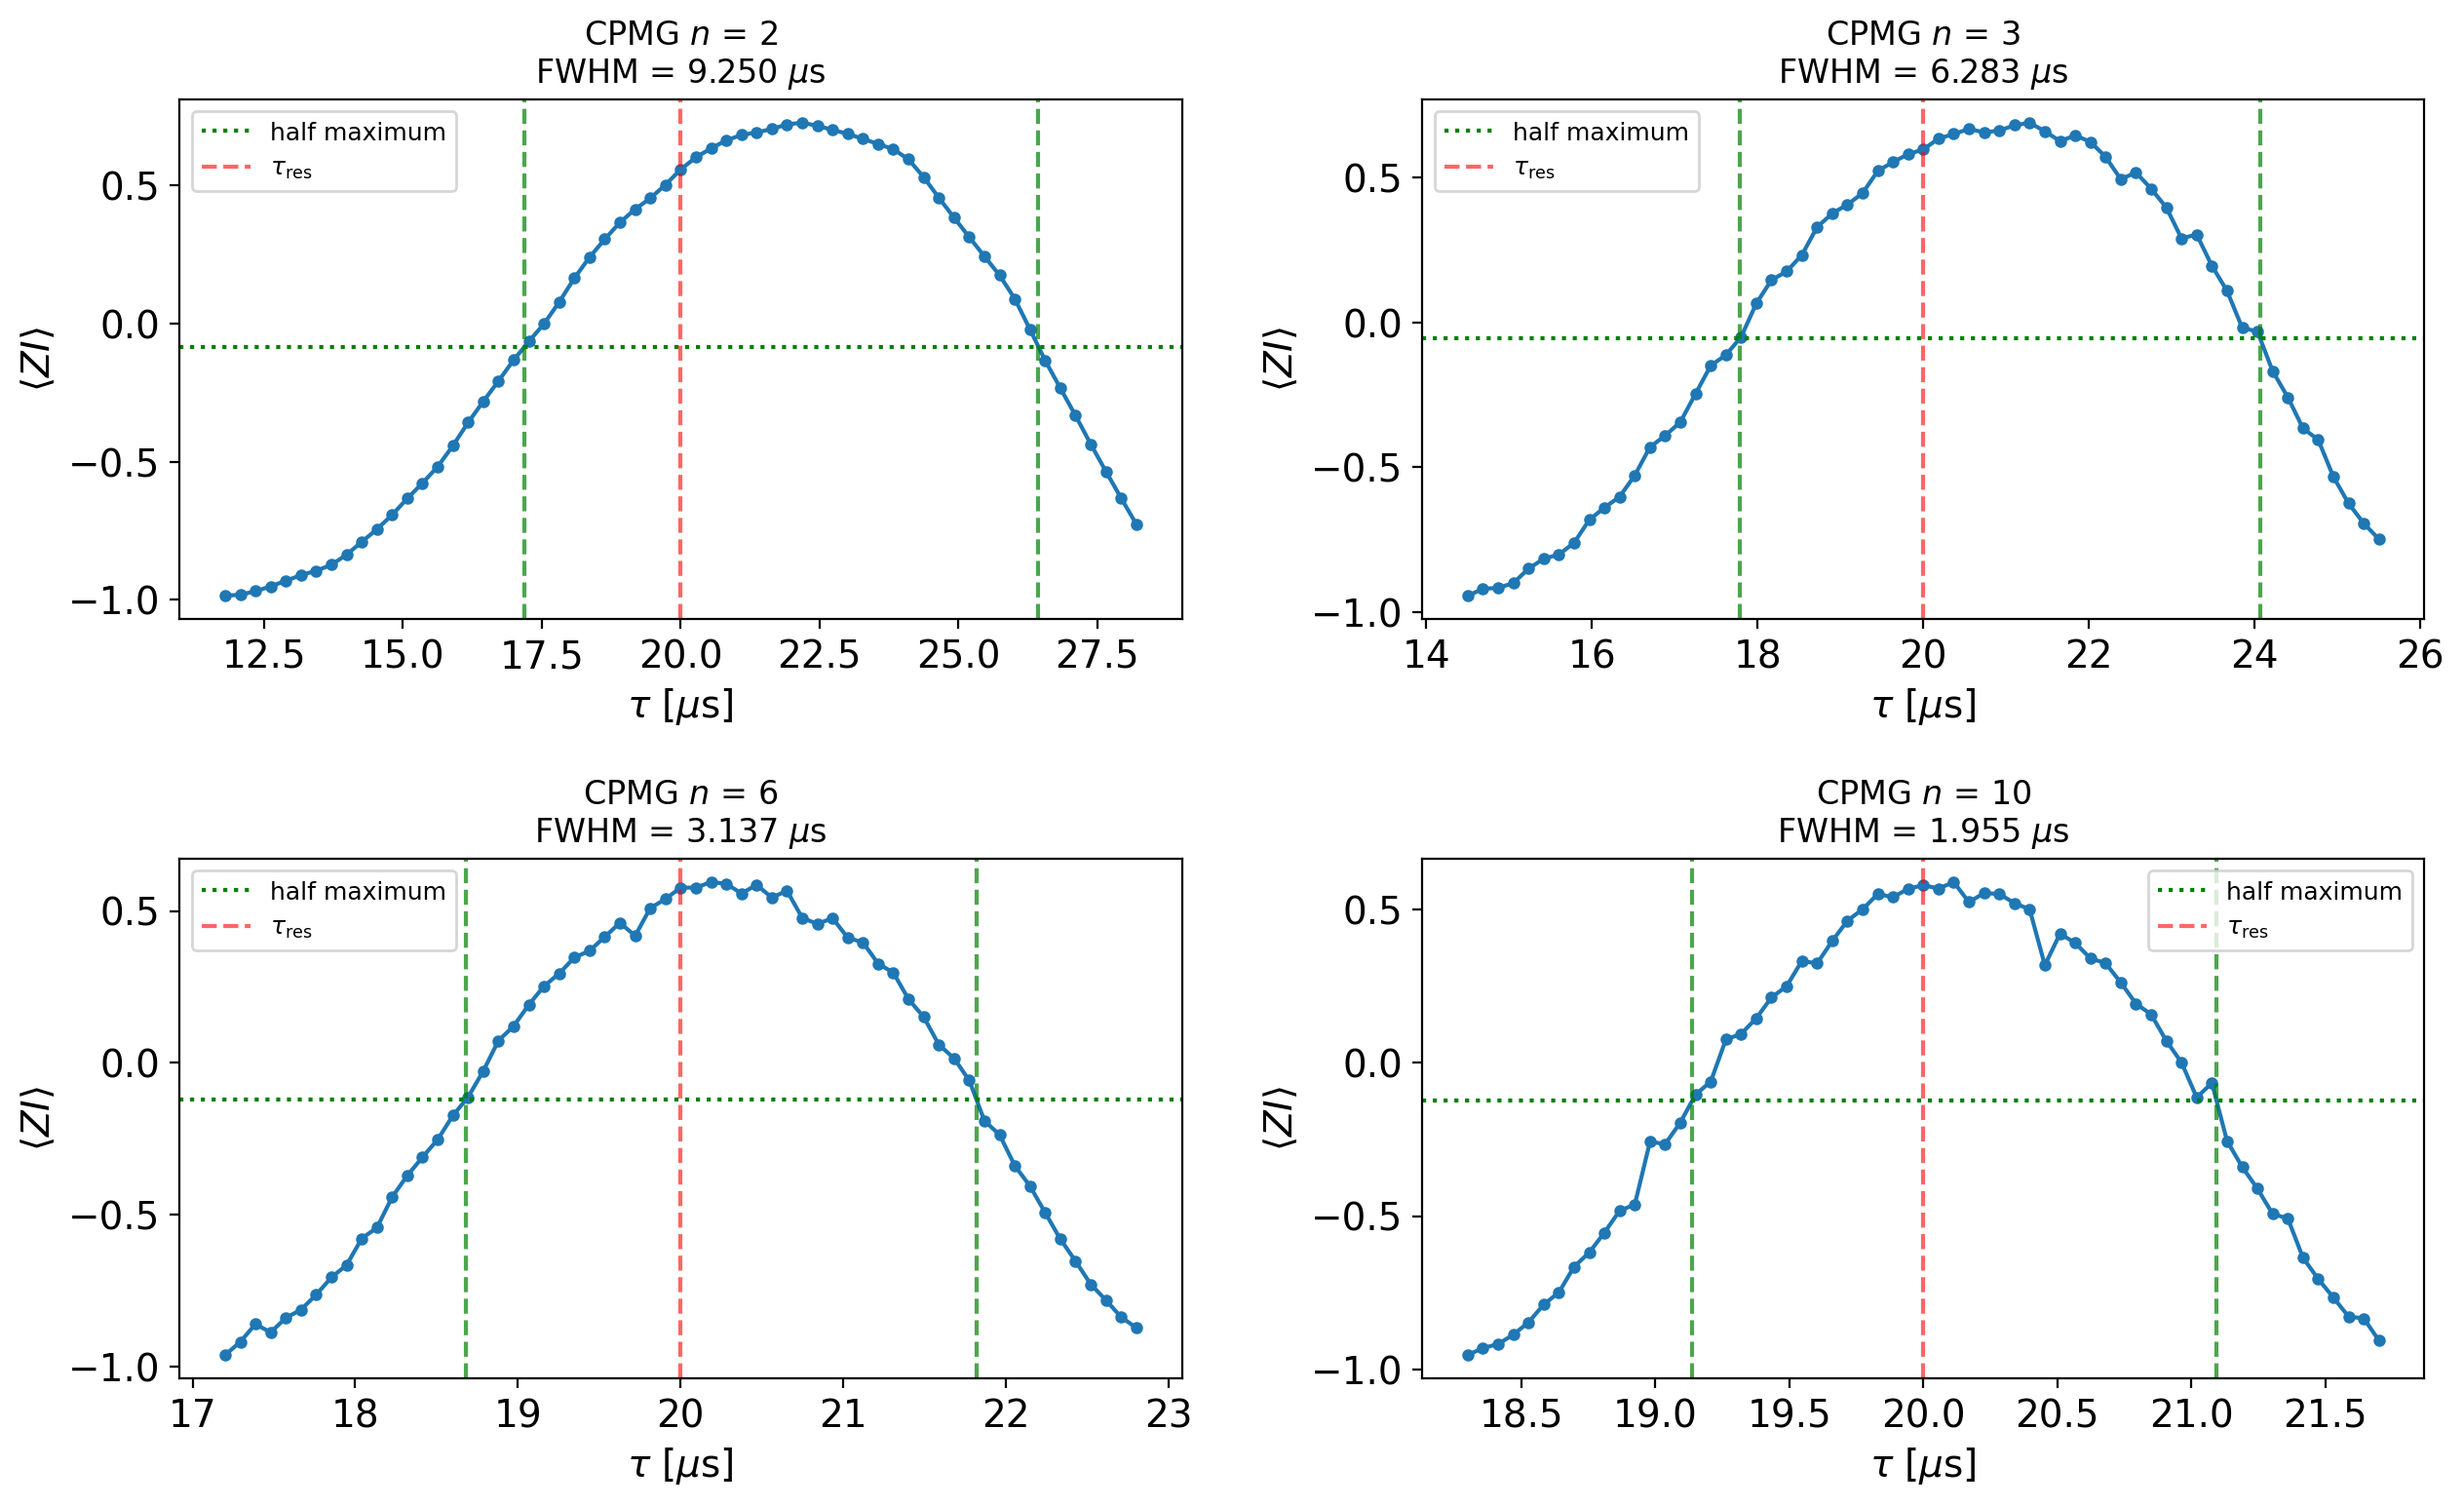

  n   FWHM [us]   n x FWHM
  2       9.250      18.50
  3       6.283      18.85
  6       3.137      18.82
 10       1.955      19.55


In [24]:
# Measure all four the same way, showing the construction so the reader can check it by eye.
fwhm_results = {}
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (n, (taus, signal)) in zip(axes.ravel(), sorted(fwhm_scans.items())):
    res = resonance_fwhm(taus, signal, tau_res=20.0)
    if res['fwhm'] is not None:
        fwhm_results[n] = res['fwhm']
    ax.plot(taus, signal, 'o-', markersize=3.5)
    ax.axhline(res['half_level'], color='g', linestyle=':', label='half maximum')
    for t_c in (res['tau_left'], res['tau_right']):
        if t_c is not None:
            ax.axvline(t_c, color='g', linestyle='--', alpha=0.7)
    ax.axvline(20.0, color='r', linestyle='--', alpha=0.6, label=r'$\tau_\mathrm{res}$')
    width = 'window too narrow' if res['fwhm'] is None else f"FWHM = {res['fwhm']:.3f} $\\mu$s"
    ax.set_title(f'CPMG $n$ = {n}\n{width}', fontsize=12)
    ax.set_xlabel(r'$\tau$ [$\mu$s]')
    ax.set_ylabel(r'$\langle ZI \rangle$')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'{"n":>3s}{"FWHM [us]":>12s}{"n x FWHM":>11s}')
for n in sorted(fwhm_results):
    print(f'{n:3d}{fwhm_results[n]:12.3f}{n * fwhm_results[n]:11.2f}')

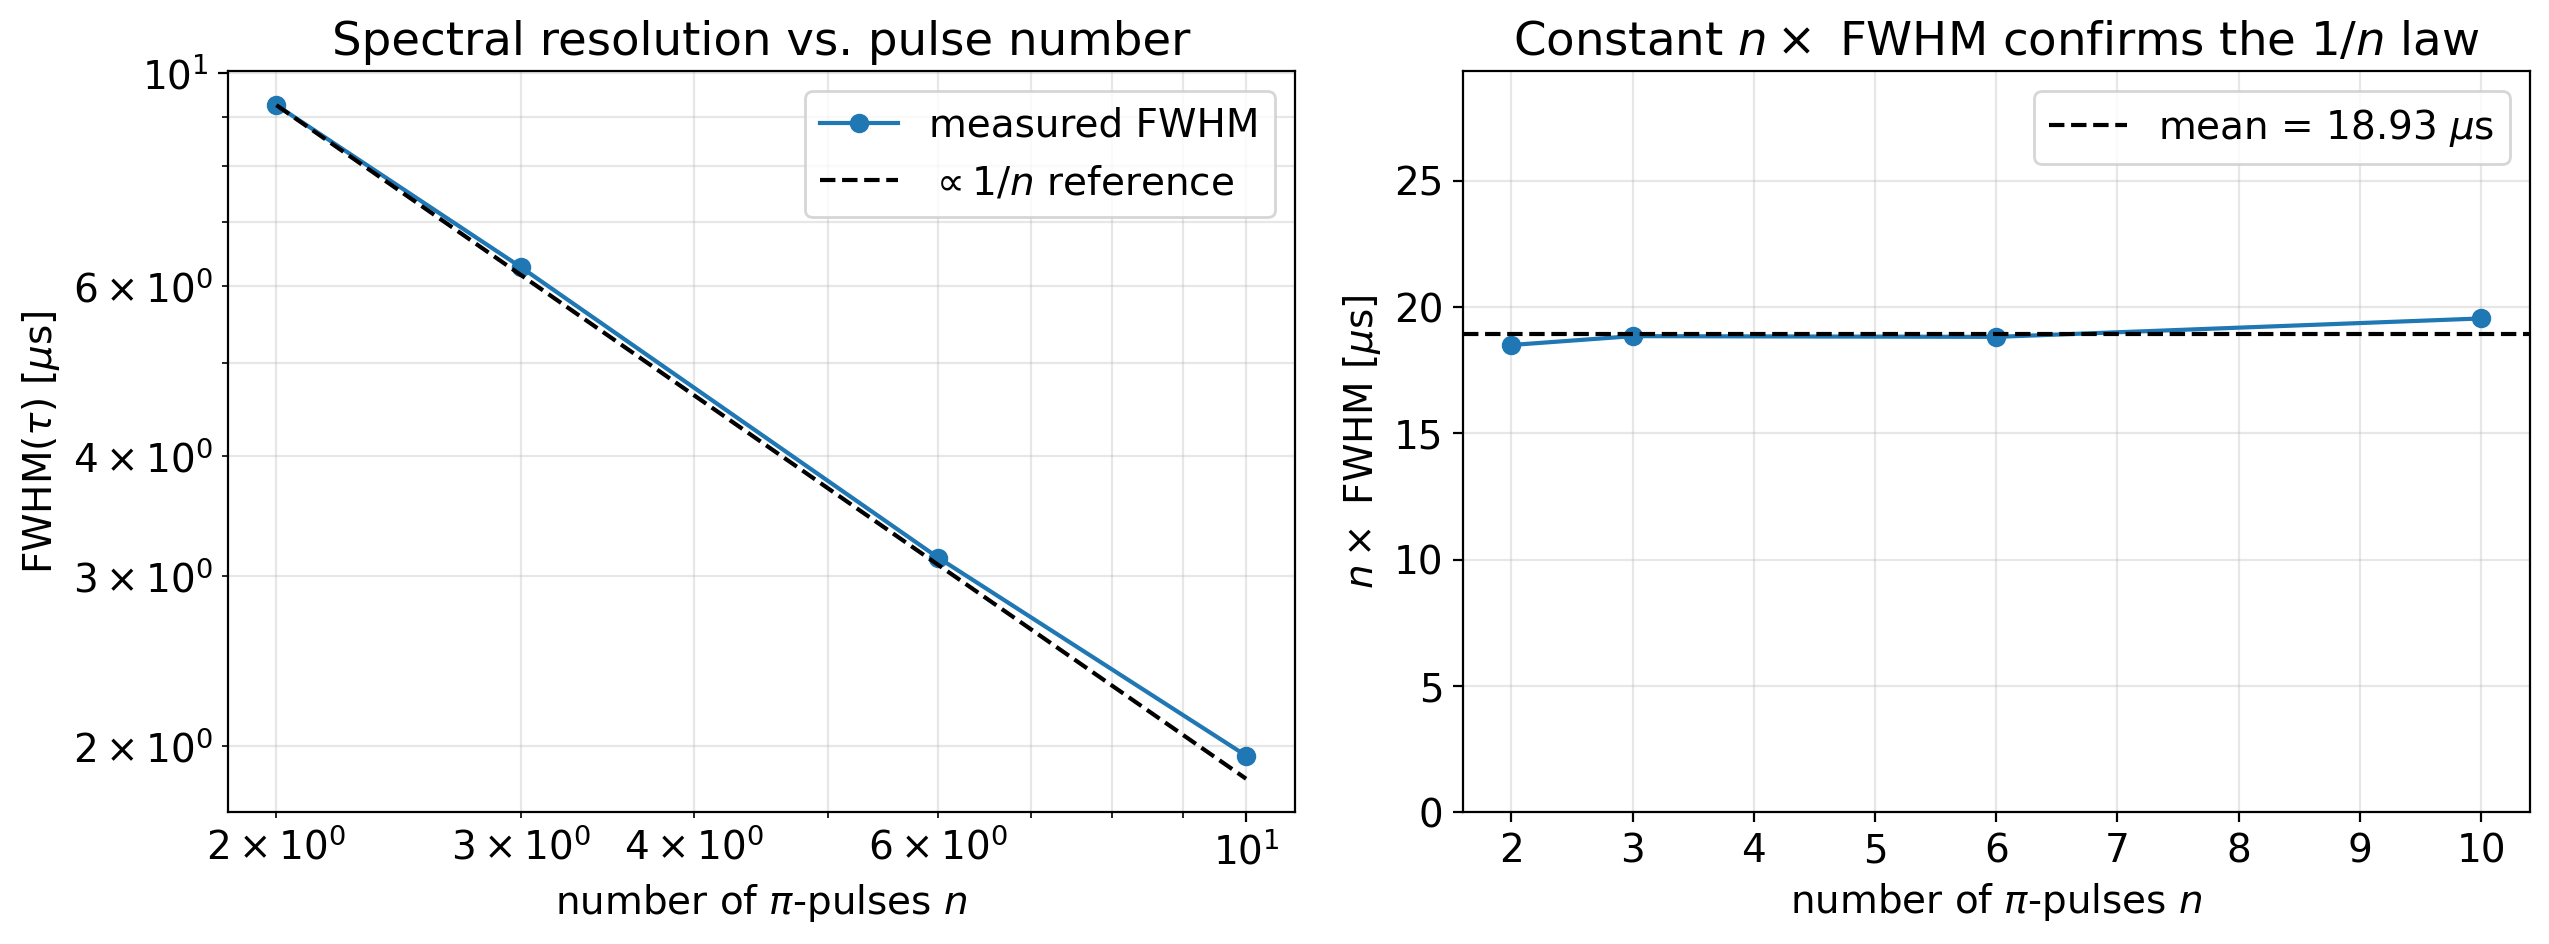

n x FWHM = 18.50, 18.85, 18.82, 19.55 us
spread about the mean: 5.5%


In [25]:
ns = sorted(fwhm_results.keys())
fwhm_vals = [fwhm_results[n] for n in ns]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].loglog(ns, fwhm_vals, 'o-', label='measured FWHM')
axes[0].loglog(ns, fwhm_vals[0] * ns[0] / np.array(ns, dtype=float), 'k--',
               label=r'$\propto 1/n$ reference')
axes[0].set_xlabel(r'number of $\pi$-pulses $n$')
axes[0].set_ylabel(r'FWHM($\tau$) [$\mu$s]')
axes[0].set_title('Spectral resolution vs. pulse number')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

products = [n * w for n, w in zip(ns, fwhm_vals)]
axes[1].plot(ns, products, 'o-')
axes[1].axhline(np.mean(products), color='k', linestyle='--',
                label=f'mean = {np.mean(products):.2f} $\\mu$s')
axes[1].set_xlabel(r'number of $\pi$-pulses $n$')
axes[1].set_ylabel(r'$n \times$ FWHM [$\mu$s]')
axes[1].set_ylim(0, 1.5 * max(products))
axes[1].set_title(r'Constant $n \times$ FWHM confirms the $1/n$ law')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

spread = (max(products) - min(products)) / np.mean(products)
print(f'n x FWHM = ' + ', '.join(f'{p:.2f}' for p in products) + ' us')
print(f'spread about the mean: {spread * 100:.1f}%')

### The $1/n$ law

The measured FWHM falls monotonically with $n$, and $n \times \text{FWHM}$ is constant to a few
percent — the Fourier-limit prediction $\Delta f \approx 1/T$ with $T \approx 2n\tau$, confirmed
directly. **Each additional $\pi$-pulse buys spectral resolution in proportion.**

One caveat is worth recording. The simulated signal also carries a small, fast variation with
$\tau$, on scales far below the resonance width, which no ideal-pulse model contains. It comes from
the finite rectangular $\pi$-pulses **off-resonantly driving the
$|0\rangle \leftrightarrow |{+1}\rangle$ transition**: the NV electron is a spin-1 system, and the
second transition sits only $2\gamma_e B_0 \approx 252$ MHz away from the $25$ MHz Rabi drive. A
little amplitude leaks into $|{+1}\rangle$ on every pulse, accumulates phase while it is there, and
interferes back at the next pulse. At the static field used here the effect is small enough not to
disturb the linewidths above, and it is suppressed further at higher $B_0$ — but it is the leading
correction to the ideal-pulse picture, and it grows with the number of pulses.

## Summary

In this notebook we simulated an AC magnetometry measurement with an NV center in
<span style="font-variant: small-caps;">Simphony</span>:

- The **phase accumulated** by the electron spin under a dynamical decoupling sequence was derived
  and expressed as an alternating-sign integral of the AC field.
- A **Hahn echo** reproduced the AC resonance at $f_{\text{AC}} = 1/(2\tau)$, matching the analytic
  filter-function prediction, and the **phase scan** showed the resonance can be located without
  prior knowledge of the AC phase.
- **CPMG** sequences with $n = 2, 3, 6, 10$ $\pi$-pulses narrowed the resonance progressively, with
  sidelobes that the ideal-pulse formula reproduces.
- The **spectral resolution** improved as $1/n$, with $n \times \text{FWHM}$ constant to a few
  percent, as the Fourier limit requires.

The main departure from the ideal-pulse picture is **off-resonant driving of the
$|0\rangle \leftrightarrow |{+1}\rangle$ transition** by the finite rectangular $\pi$-pulses, which
adds a small fast variation of the signal with $\tau$ and accumulates with the number of pulses.
Suppressing it calls for either a larger static field or **shaped pulses** whose spectrum has less
weight at the unwanted transition — see the `3_tutorial_autodiff_gate_optimization` notebook for
optimizing pulse shapes against gate infidelity with `add_discrete_pulse()` and
`jax.value_and_grad`.